In [1]:
import numpy as np
from sympy import var
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from scipy import integrate
from numba import jit
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon
plt.rc('font', size=18) 

from scipy.interpolate import interp1d
from scipy.integrate import odeint

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', family='serif')
plt.rc('font', size='22')
#plt.rcParams['figure.dpi'] = 150
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1.5

In [3]:
from classy import Class

#Start by specifying the cosmology  - planck best fit
h = 0.6766
Omega_b = 0.02242/h**2
Omega_cdm = 0.11933/h**2
Omega_m = Omega_cdm+Omega_b
A_s = 2.105e-9 
n_s = 0.9665

#Create a params dictionary
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc # is also set to 10 later
params = {'output':'mPk,mTk',
             'non linear':'halofit',
             'Omega_b':Omega_b,
             'Omega_cdm':Omega_cdm,#Omega_m-Omega_b,#
             'h':h,
             'n_s':n_s,
             'A_s':A_s,#'n_s':n_s,'sigma8':0.828,#
             'P_k_max_1/Mpc':k_max,
             'z_max_pk':10. #Default value is 10
}

#Initialize the cosmology and compute everything
cosmo = Class()
cosmo.set(params)
cosmo.compute()

## define all derivatives wrt to comoving distance

$\frac{df}{d ln(d)}=\frac{d d}{d ln(d)}\frac{dz}{dd}\frac{df}{dz}=d \times(1/\frac{dd}{dz})\frac{df}{dz}$

In [4]:
class CosmologicalFunctions:
    def __init__(self,cosmo,survey='EUCLID'):
        """
            take in Class and spit out stuff and create bunch of functions needed to compute bispectrum
        """
        self.cosmo = cosmo
        baLCDM = cosmo.get_background()

        f_cl = baLCDM['gr.fac. f']
        D_cl = baLCDM['gr.fac. D']
        z_cl = baLCDM['z']
        H_cl = baLCDM['H [1/Mpc]']
        xi_cl = baLCDM['comov. dist.']
        t_cl = baLCDM['conf. time [Mpc]']
        
        self.z_cl = z_cl#save for later
        self.Om_0 = cosmo.get_current_derived_parameters(['Omega_m'])['Omega_m']
        self.h = cosmo.get_current_derived_parameters(['h'])['h']
        
        #define functions and add in h
        self.H_c = interp1d(z_cl,H_cl*(1/(1+z_cl))/self.h,kind='cubic') # now in h/Mpc!
        self.dH_c = interp1d(z_cl,np.gradient(H_cl*(1/(1+z_cl))/self.h,z_cl),kind='cubic') # derivative wrt z
        self.ddH_c = interp1d(z_cl,np.gradient(self.dH_c(z_cl),z_cl),kind='cubic') # second derivative wrt z
        self.comoving_dist = interp1d(z_cl,xi_cl*self.h,kind='cubic') # just use class background as quick
        self.d_to_z = interp1d(xi_cl*self.h,z_cl,kind='cubic') # useful to map other way
        self.f_intp = interp1d(z_cl,f_cl,kind='cubic')#get f #omega_mz = Omega_m *(1+zt)**3 /(Omega_m *(1+zt)**3 + Omega_l)
        self.D_intp = interp1d(z_cl,D_cl,kind='cubic')
        self.dD_dz = interp1d(z_cl,np.gradient(D_cl,z_cl),kind='cubic')
        self.conf_time = interp1d(z_cl,self.h*t_cl,kind='cubic')#convert between the two
        #misc
        self.c = 2.99792*10**5 #km/s
        self.H0 = 100/self.c #[h/Mpc]
        self.Om = lambda xx: self.Om_0 * (self.H0**2 / self.H_c(xx)**2) * (1+xx)
        
        #define bias stuff
        if survey=='EUCLID':
            self.b_1  =  lambda xx: 0.9 + 0.4*xx
        elif survey=='BGS':
            self.b_1 =  lambda xx: 1.34/self.D_intp(xx)
        else:
            self.b_1  =  lambda xx: 0.9 + 0.4*xx
            
        self.g_2 = lambda xx: -(2/7)*(self.b_1(xx)-1)# 0.524-0.547*self.b_1(xx)+0.046*self.b_1(xx)**2#
        self.b_2 = lambda xx: 0.412 - 2.143*self.b_1(xx) +0.929*self.b_1(xx)**2 + 0.008*self.b_1(xx)**3 + 4/3 * self.g_2(xx)#-0.1*np.sqrt(1+xx)#
        
        self.z_samps = np.linspace(0.05, 10, 10000)#defined over appropiate range for numerical derivs
        
        #get derivs of these redshift dependent functions
        func_deriv_list = self.lnd_derivatives([self.b_1,self.b_2,self.g_2,self.f_intp,self.D_intp])
        self.b1_d,self.b2_d,self.g2_d,self.f_d,self.D_d = func_deriv_list
        func_second_deriv_list = self.lnd_derivatives(func_deriv_list)
        self.b1_dd,self.b2_dd,self.g2_dd,self.f_dd,self.D_dd = func_second_deriv_list
        
        if survey=='EUCLID':
            self.z_survey = np.linspace(0.9,1.8) 
            self.be_survey= lambda xx: -7.29 + 0.470*xx + 1.17*xx**2 - 0.290*xx**3
            self.Q_survey = lambda xx: 0.583 + 2.02*xx - 0.568*xx**2 + 0.0411*xx**3
            #self.v_z = lambda zz: 8.85*zz**1.65 *np.exp(-0.777*zz)
            self.n_g = lambda zz: 0.0193*zz**(-0.0282) *np.exp(-2.81*zz)

        elif survey=='BGS':
            self.z_survey = np.linspace(0.05,0.6)
            #z_tab = [0.05,0.15,0.25,0.35,0.45,0.55] #not used as we just use bin_volume
            #v_tab = [0.04,0.23,0.58,1.04,1.55,2.08] #Gpc^3
            #self.v_z = interp1d(z_tab,v_tab)
            self.n_g = lambda zz: 0.023*zz**(-0.471)*np.exp(-5.17*zz)-0.002 #fitting from Maartens
            self.be_survey= lambda xx: -2.25 - 4.02*xx + 0.318*xx**2 - 14.6*xx**3
            self.Q_survey = lambda xx: 0.282 + 2.36*xx + 2.27*xx**2 + 11.1*xx**3
        elif survey == 'model1':
            self.z_survey = np.linspace(0.9,1.8) 
            z_euclid = euclid_data[:,0]
            self.be_survey = interp1d(z_euclid, euclid_data[:,1])
            self.Q_survey = interp1d(z_euclid,  euclid_data[:,2])
        else:
            self.z_survey = np.linspace(0.9,1.8) 
            self.be_survey = lambda xx: 0*xx
            self.Q_survey = lambda xx:  0*xx #+ 2/5
            
    def get_class_powerspectrum(self,kk,zz=0): #h are needed to convert to 1/Mpc for k then convert pk back to (Mpc/h)^3
        return np.array([self.cosmo.pk_lin(ki, zz) for ki in kk*self.h])*h**3
    
    def get_Pk_NL(self,zz=0): # for halofit non-linear power spectrum
        k = np.logspace(-5, np.log10(k_max), num=1000)
        pk_nl = interp1d(k,np.array([self.cosmo.pk(ki, zz) for ki in k*self.h])*h**3)
        return pk_nl
    
    def get_class_powerspectrumNL(self,kk,zz): #h are needed to convert to 1/Mpc for k then convert pk back to (Mpc/h)^3
        return np.array([self.cosmo.pk(ki, zz) for ki in kk*self.h])*h**3

    def get_pkinfo_z(self,k,z):
        Plin = self.get_class_powerspectrum(k,0)#just always get present day power spectrum
        Pk = interp1d(k,Plin)#get linear power spectrum
        self.Pk = Pk
        Pk_d = interp1d(k,np.gradient(Plin,k))
        Pk_dd = interp1d(k,np.gradient(Pk_d(k),k))
        return Pk,Pk_d,Pk_dd
    
    def Pk_phi(self,k,cosmo=cosmo, k0=0.05, units=True):
        """Power spectrum of the Bardeen potential Phi in the matter-dominated era - k in units of h/Mpc.
        """
        k_pivot = k0/h
        resp = (9.0/25.0) * cosmo.get_current_derived_parameters(['A_s'])['A_s'] * (k/k_pivot)**(cosmo.get_current_derived_parameters(['n_s'])['n_s'] - 1.0)

        if units:
            resp *= 2*np.pi**2.0/k**3.0    #[Mpc/h]^3

        return resp

    def M(self,k, z):
        """The scaling factor between the primordial scalar power spectrum and the late-time matter power spectrum
        """
        return np.sqrt(self.D_intp(z)**2 *self.Pk(k) / self.Pk_phi(k) )

    def solve_second_order_KC(self):
        c = 2.99792*10**5 #km/s
        def F_func(u,zz): # so variables are F and H and D
            f,fd = u # unpack u vector
            D_zz = self.D_intp(zz)
            return [fd,(-self.H_c(zz)*self.dH_c(zz)*(1+zz)**2 *fd + ((3*(self.H0)**2 * self.Om_0 *(1+zz))/(2))*(f+D_zz**2))/(self.H_c(zz)**2 *(1+zz)**2)]
        
        odeint_zz = np.linspace(20,0.05,int(1e+5))# so z=20 should be pretty much matter dominated

        #set initial params for F
        F0 = [(3/7)*self.D_intp(odeint_zz[0])**2,(3/7)*2*self.D_intp(odeint_zz[0])*self.dD_dz(odeint_zz[0])]
        sol1 = odeint(F_func,F0,odeint_zz)
        K = (sol1[:,0]/self.D_intp(odeint_zz)**2)
        C = sol1[:,1]/(2*self.D_intp(odeint_zz)*self.dD_dz(odeint_zz))
        self.K_intp = interp1d(odeint_zz,K,kind='cubic')
        self.C_intp = interp1d(odeint_zz,C,kind='cubic')
    
    def lnd_derivatives(self,functions_to_differentiate,z_range= [0]):
        """
            calculates derivatives of a list of functions wrt log comoving dist numerically
        """
        if len(z_range) == 1:
            z_range= self.z_samps

        # Store first derivatives in a list
        function_derivatives = []

        for func in functions_to_differentiate:
            # Calculate numerical derivatives of the function with respect to ln(d)
            derivative_func = interp1d(z_range, np.gradient(func(z_range), np.log(self.comoving_dist(z_range))))
            function_derivatives.append(derivative_func)

        return function_derivatives

    def get_params(self,k1,k2,theta,zz,nonlinear=False):
        """
            return arrays of redshift and k dependent parameters
        """
        self.solve_second_order_KC()#get K and C
        
        k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))#get k3 from triangle condition
        k3 = np.where(k3==0,1e-3,k3)
        
        k = np.logspace(-5, np.log10(k_max), num=1000)
        Pk,Pk_d,Pk_dd = self.get_pkinfo_z(k,0)
        Pk1 = Pk(k1)
        Pk2 = Pk(k2)
        Pk3 = Pk(k3)

        Pkd1 = Pk_d(k1)
        Pkd2 = Pk_d(k2)
        Pkd3 = Pk_d(k3)

        Pkdd1= Pk_dd(k1)
        Pkdd2 = Pk_dd(k2)
        Pkdd3 = Pk_dd(k3)
        
        if nonlinear:
            Pk_NL = self.get_Pk_NL(zz=0)
            Pk1 = Pk_NL(k1)
            Pk2 = Pk_NL(k2)
            Pk3 = Pk_NL(k3)
        #redshift dependendent terms
        d = self.comoving_dist(zz)
        
        K = 3/7
        C = 3/7
        if False:
            K = self.K_intp(zz)
            C = self.C_intp(zz)

        f = self.f_intp(zz)
        D1 = self.D_intp(zz)
        b1 = self.b_1(zz)
        b2 = self.b_2(zz)
        g2 = self.g_2(zz)
        return k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2

    def get_derivs(self,zz):
        #1st deriv
        fd = self.f_d(zz)
        Dd = self.D_d(zz)
        gd2 = self.g2_d(zz)
        bd2 = self.b2_d(zz)
        bd1 = self.b1_d(zz)
        #2nd deriv
        fdd = self.f_dd(zz)
        Ddd = self.D_dd(zz)
        gdd2 = self.g2_dd(zz)
        bdd2 = self.b2_dd(zz)
        bdd1 = self.b1_dd(zz)
        return fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
    
    def get_PNGparams(self,fNL,zz,k1,k2,k3):
        delta_c = 1.686
        bL10 = lambda xx: self.b_1(xx) - 1
        bL20 = lambda xx: self.b_2(xx) - (8/21)*bL10(xx)

        bL01 = lambda xx: 2*delta_c*fNL*bL10(xx)
        bL11 = lambda xx: 2*fNL*(delta_c*bL20(xx)-bL10(xx))
        bL02 = lambda xx: 4*fNL**2 * delta_c*(delta_c*bL20(xx)-2*bL10(xx))

        bE01 = bL01
        bE11 = lambda xx: bL01(xx) + bL11(xx)
        bE02 = bL02

        alphak1 = self.M(k1, 0)
        alphak2 = self.M(k2, 0)
        alphak3 = self.M(k3, 0)
        return fNL,1*bE01(zz),1*bE11(zz),0*bE02(zz),alphak1,alphak2,alphak3
    
    def get_beta_funcs(self,zz):
        """
            Function that relies on biases and functions defined above to return beta coefficients
            from paper 1711.01812v4
        """
        #these derivs here are wrt to conformal time so we convert to derivs wrt to z
        #d/dt = d a/dt d/da = a H dz/da d/dz =  -(1+z) H d/dz # everything here is conformal both t and H
        #d^2/d^2 t = (1+z)^2 H^2 d^2/d z^2 + H(1+z)(H+(1+z)H')d/dz
        
        dQ_dz = interp1d(self.z_survey,np.gradient(self.Q_survey(self.z_survey),self.z_survey))
        dbe_dz = interp1d(self.z_survey,np.gradient(self.be_survey(self.z_survey),self.z_survey))
        db1_dz = interp1d(self.z_samps,np.gradient(self.b_1(self.z_samps),self.z_samps))
        
        dH_dt = lambda xx: -(1+xx)*self.H_c(xx)*self.dH_c(xx)
        dH_dt2 = lambda xx: (1+xx)**2 *self.H_c(xx)**2 *self.ddH_c(xx)+self.H_c(xx)*(1+xx)*(self.H_c(xx)+(1+xx)*self.dH_c(xx))*self.dH_c(xx)#should just check with doing it numerically as is easier
        #self.dH22 = interp1d(self.z_cl,np.gradient(dH_dt(self.z_cl),self.conf_time(self.z_cl)))
        self.dH_dt = dH_dt                   
        dQ_dt = lambda xx: -(1+xx)*self.H_c(xx)*dQ_dz(xx)
        dbe_dt = lambda xx: -(1+xx)*self.H_c(xx)*dbe_dz(xx)#0*xx-1.6*1e-4
        db1_dt = lambda xx: -(1+xx)*self.H_c(xx)*db1_dz(xx)  
        self.Q = self.Q_survey
        self.b_e = self.be_survey

        partdQ=0
        partdb1=0
        
        #from 1st order petrubation theory
        self.gr1 = lambda xx: self.H_c(xx)*self.f_intp(xx)*(self.b_e(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2)
        self.gr2 = lambda xx: self.H_c(xx)**2 *(self.f_intp(xx)*(3-self.b_e(xx))+ (3/2)*self.Om(xx)*(2+self.b_e(xx)-self.f_intp(xx)-4*self.Q(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2))
        self.grd1 = self.lnd_derivatives([self.gr1],self.z_survey)[0]#get derivative for 1st order coef
        
        beta = np.empty(20,dtype=object)
        beta[6] = lambda xx: self.H_c(xx)**2 * ((3 / 2) * self.Om(xx) * (2 - 2 * self.f_intp(xx)+ self.b_e(xx) - 4 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[7] = lambda xx: self.H_c(xx)**2 * (self.f_intp(xx)* (3 - self.b_e(xx)))
        beta[8] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx) * (2 - self.f_intp(xx) - 2 * self.Q(xx)) + self.f_intp(xx)**2 * (4 + self.b_e(xx) - self.b_e(xx)**2 + 4 * self.b_e(xx) * self.Q(xx) - 6 * self.Q(xx) - 4 * self.Q(xx)**2 + 4 * partdQ + 4 * (dQ_dt(xx) / self.H_c(xx)) -(dbe_dt(xx) / self.H_c(xx)) - (2 / (self.comoving_dist(xx)**2 * self.H_c(xx)**2)) * (1 - self.Q(xx) + 2 * self.Q(xx)**2 - 2 * partdQ) - (2 / (self.comoving_dist(xx) * self.H_c(xx))) * (3 - 2 * self.b_e(xx) + 2 * self.b_e(xx) * self.Q(xx) - self.Q(xx) - 4 * self.Q(xx)**2 + ((3 * dH_dt(xx)) / (self.H_c(xx)**2)) * (1 - self.Q(xx)) + 4 * partdQ + 2 * (dQ_dt(xx) / self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((3 * dH_dt(xx)) / (self.H_c(xx)**2))) + (dH_dt2(xx) / self.H_c(xx)**3)))
        beta[9] = lambda xx: self.H_c(xx)**2 * ( -(9 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[10] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx))
        beta[11] = lambda xx: self.H_c(xx)**2 * ( (3/2 ) * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) + 3 * self.Om(xx) * self.f_intp(xx)- self.f_intp(xx)**2 * (-1 + self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 + self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[12] = lambda xx: self.H_c(xx)**2 * ( -3 * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) - self.f_intp(xx)* ( self.b_1(xx) * (self.f_intp(xx)- 3 + self.b_e(xx)) + (db1_dt(xx) / self.H_c(xx)) ) + (3 / 2) * self.Om(xx) * (self.b_1(xx) * (2 + self.b_e(xx) - 4 * self.Q(xx) - 2 * ((1 - self.Q(xx))/(self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) ) + db1_dt(xx) /self.H_c(xx) + 2 * (2 - (1 / (self.comoving_dist(xx) * self.H_c(xx))) ) * partdb1 ) )    
        beta[13] = lambda xx: self.H_c(xx)**2 * (( (9 / 4) * self.Om(xx)**2 + (3 / 2) * self.Om(xx) * self.f_intp(xx)* (1 - (2 * self.f_intp(xx)) + 2 * self.b_e(xx) - 6 * self.Q(xx) - ((4 * (1 - self.Q(xx)))/(self.comoving_dist(xx) * self.H_c(xx))) - ((3 * dH_dt(xx)) / self.H_c(xx)**2) ) ) + ( self.f_intp(xx)**2 * (3 - self.b_e(xx)) ) )
        beta[14] = lambda xx: self.H_c(xx) * ( - (3 / 2) * self.Om(xx) * self.b_1(xx))
        beta[15] = lambda xx: self.H_c(xx) * 2 * self.f_intp(xx)**2
        beta[16] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_1(xx) * (self.f_intp(xx)+ self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)) + (db1_dt(xx) / self.H_c(xx)) + 2 * (1 - (1 / (self.comoving_dist(xx) * self.H_c(xx)))) * partdb1 ))
        beta[17] = lambda xx: self.H_c(xx) * (- (3 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[18] = lambda xx: self.H_c(xx) * ( (3 / 2) * self.Om(xx) * self.f_intp(xx) - self.f_intp(xx)**2 * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((4 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) + (3 * dH_dt(xx)/ self.H_c(xx)**2)) )
        beta[19] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))

        self.beta = beta
        
        #get betad - derivatives wrt to ln(d)        # these are limited in range to euclid currently
        betad = np.empty(20,dtype=object)
        betad[14:20] = np.array(self.lnd_derivatives(beta[14:20],self.z_survey),dtype=object)#14-19

        self.betad = betad
        all_betas = np.concatenate((np.array([self.gr1,self.gr2,self.grd1]),beta[6:],betad[14:20]))
        return [all_betas[i](zz) for i in range(len(all_betas))]


In [5]:
import sys
sys.path.append('bk_terms/')
from zeroth_order import *
from WA1 import *
from RR1 import *
from WA2_terms import *
from WA2_termstest import WA2 as WA2_
from RR2_terms import *
from RR2_terms13 import RR2 as RR2_
from WARR_terms import *
from GR_terms import *   
from GRmix_terms import *
from cov import *
from watest import *
from watest1 import *

In [15]:
from bk_terms_new.WA1 import WA1 as WA1_new
from bk_terms_new.WA2 import WA2 as WA2_new
from bk_terms_new.RR1 import RR1 as RR1_new
from bk_terms_new.RR2 import RR2 as RR2_new
from bk_terms_new.WARR import WARR as WARR_new

## General plots

Text(0, 0.5, '$ \\text{Imag}[B_{\\ell=1}(k1=0.1,k2=0.05)]/B_0 $')

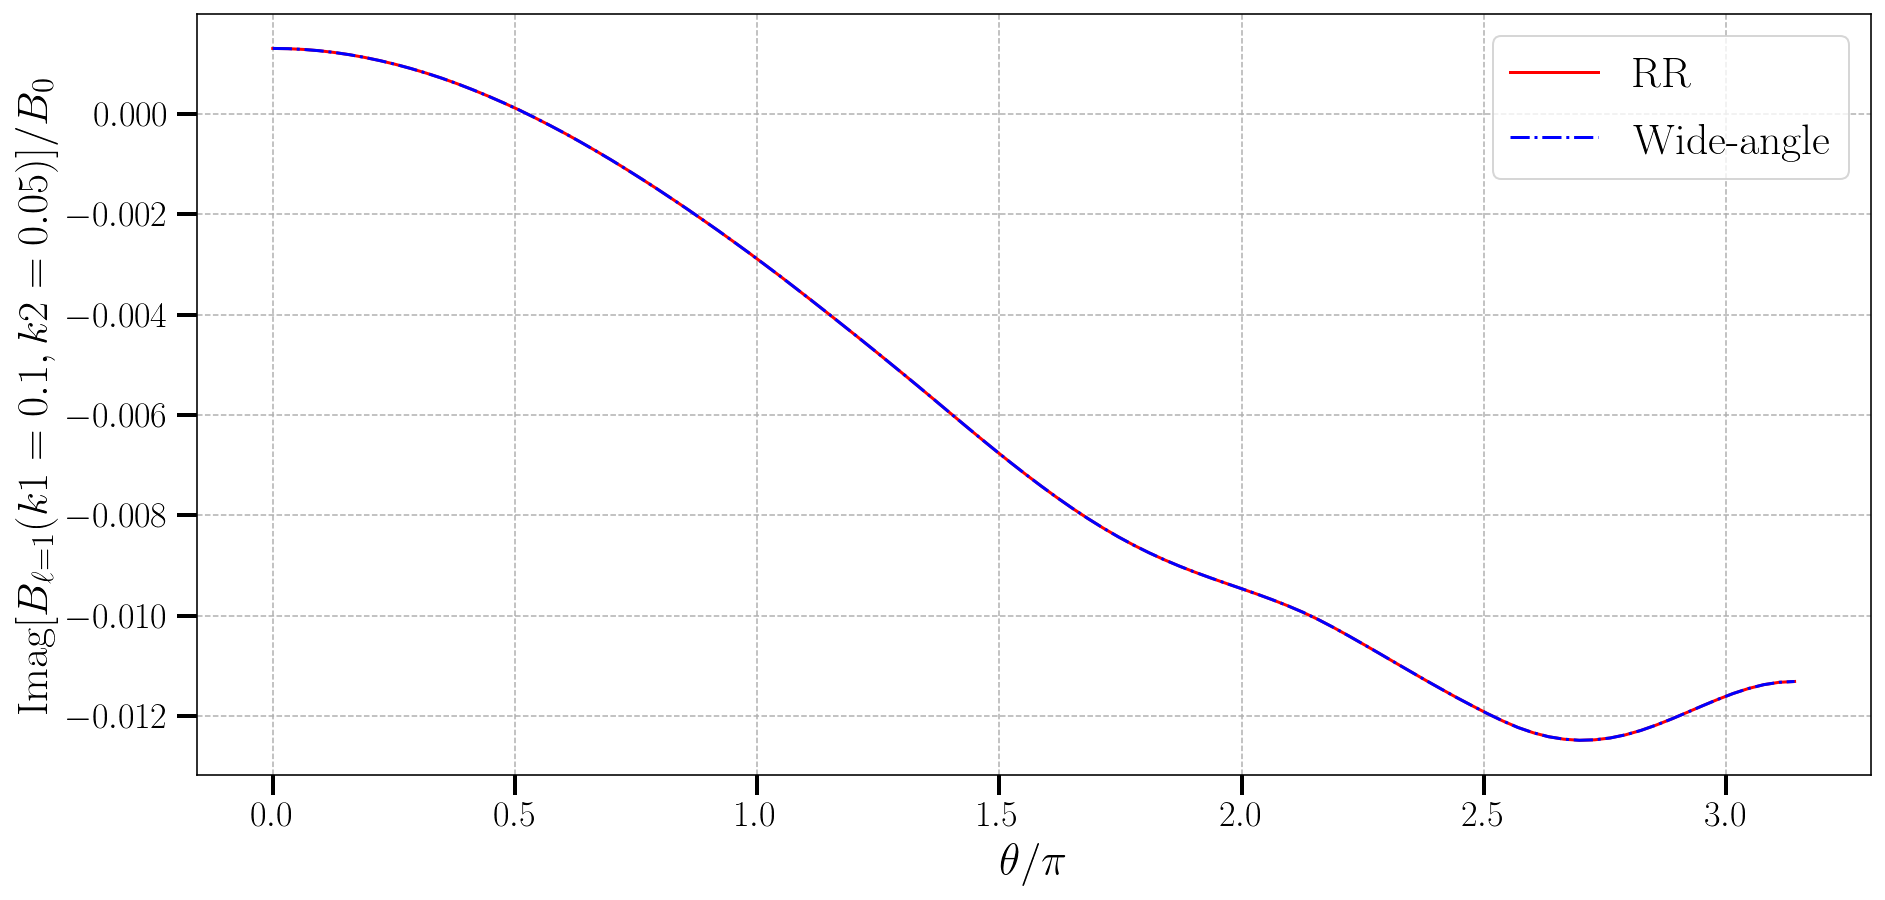

In [7]:
plt.figure(figsize=(15,7))

#ok get some equilateral triangles...
if False:
    k1 = np.geomspace(1e-4,1,1000)
    k2 = 0.9*k1
    k3 = 0.5*k1
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
else:
    k1=0.04;k2=k1/2
    theta = np.linspace(0,np.pi,100)#2*np.pi/3#np.pi#
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))


zz=1

cosmo_functions = CosmologicalFunctions(cosmo)#'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

r=0;s=0
plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='red',label='RR')
#plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='blue',label='Wide-angle')
#plt.plot(theta,WA1_new.l1(params,r,s).imag/GR0.l0(params),'--',color='blue',label='Wide-angle')
#plt.plot(theta,WA1test.l1(params,r,s).imag/GR0.l0(params),'--',color='blue',label='Wide-angle')
plt.plot(theta,RR1.l1(params,derivs,r,s).imag/GR0.l0(params),'-.',color='blue',label='Wide-angle')
#plt.plot(theta,(WA1test1.l1(params,r,s)+WA1test.l1(params,r,s)).imag/GR0.l0(params),'-.',color='black',label='Wide-angle')

r=1;s=0
#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'--',color='red',label='RR')
#plt.plot(theta,(RR1_new.l1(params,derivs,r,s).imag),'--',color='red',label='RR')
#plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='orange',label='Wide-angle')
#plt.plot(theta,WA1test.l1(params,r,s).imag/GR0.l0(params),'--',color='orange',label='Wide-angle')
#plt.plot(theta,WA1test1.l1(params,r,s).imag/GR0.l0(params),'--',color='orange',label='Wide-angle')


r=0;s=1
#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-.',color='red',label='RR')
#plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='grey',label='Wide-angle')
#plt.plot(theta,WA1test.l1(params,r,s).imag/GR0.l0(params),'-.',color='grey',label='Wide-angle')
#plt.plot(theta,WA1test1.l1(params,r,s).imag/GR0.l0(params),'-.',color='grey',label='Wide-angle')


r=1/3;s=1/3;
#plt.plot(k3,WAGR.l0(params,betas,r,s).real/GR0.l0(params))
#plt.plot(k3,(r*WAGR.l0(params,betas,1,0)+s*WAGR.l0(params,betas,0,1)+(1-r-s)*WAGR.l0(params,betas,0,0)).real/GR0.l0(params))
#plt.plot(k3,RRGR.l0(params,derivs,betas,r,s).real/GR0.l0(params))
#plt.plot(k3,(r*RRGR.l0(params,derivs,betas,1,0)+s*RRGR.l0(params,derivs,betas,0,1)+(1-r-s)*RRGR.l0(params,derivs,betas,0,0)).real/GR0.l0(params))

#plt.plot(theta/np.pi,RR2.l0(params,derivs,1/3,1/3)/GR0.l0(params))
#plt.plot(theta/np.pi,WARR.l0(params,derivs,1/3,1/3)/GR0.l0(params))
#plt.plot(theta/np.pi,np.zeros_like(theta),color='grey',linestyle='--')

#plt.ylim(-1,1)
#plt.xlim(0,1)
plt.grid(ls='--',lw=0.75)

plt.legend()
plt.xlabel(r'$\theta/ \pi\,$')
plt.ylabel(r'$ \text{Imag}[B_{\ell=1}(k1=0.1,k2=0.05)]/B_0 $')

In [8]:
print(np.sqrt(3))

1.7320508075688772


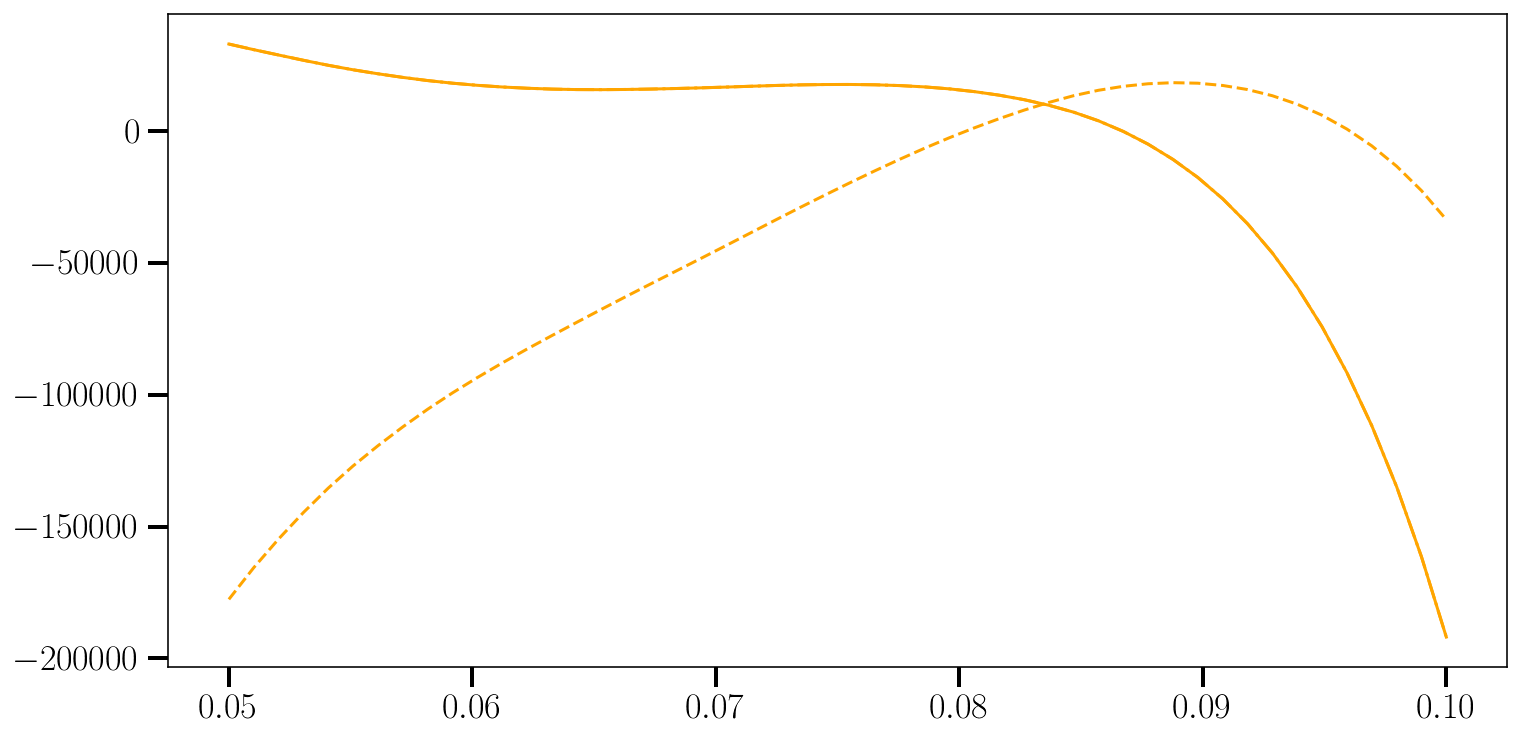

In [24]:
zz=1.0
k_fix = 0.01

if False:
    k1=0.08#np.linspace(0.01,0.1)#
    k2=k1/2
    theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
else:#squeeze
    k1 = np.linspace(0.05,0.1)
    k2= 0.05
    k3 = k2
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))


cosmo_functions = CosmologicalFunctions(cosmo)#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

plt.figure(figsize=(12,6))


r=0;s=0
#plt.plot(k3,(WA2.l0(params,r,s))/(WA2_new.l0(params,r,s)),'-.',label='WA',color='blue')
#plt.plot(k3,(WA2_new.l0(params,r,s)),'--',label='WA',color='red')
#plt.plot(k3,(WA2_new.l0(params,r,s))[1],'--',label='WA',color='red')
#plt.plot(k3,(WA2_new.l0(params,r,s))[2],'--',label='WA',color='red')
#plt.plot(k3,(RR2_new.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'--',label='RR',color='red')
plt.plot(k1,(WA2.l2(params,r,s)),'-',label='WA/RR',color='orange')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-',label='WA/RR',color='black')
r=1;s=0
#plt.plot(k3,(RR2_new.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'--',label='RR',color='red')
#plt.plot(k3,(WA2.l0(params,r,s)),'--',label='WA',color='blue')
#plt.plot(k3,(WA2_new.l0(params,r,s))[0],'--',label='WA',color='green')
#plt.plot(k3,(WA2_new.l0(params,r,s))[1],'--',label='WA',color='green')
#plt.plot(k3,(WA2_new.l0(params,r,s))[2],'--',label='WA',color='green')

#plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='blue')
#plt.plot(k3,(WA2_new.l0(params,r,s)),'--',label='WA',color='red')
#plt.plot(k3,(RR2_.l0(params,derivs,r,s))/(RR2.l0(params,derivs,r,s)),'--',label='RR',color='red')
plt.plot(k1,(WA2.l2(params,r,s)),'--',label='WA/RR',color='orange')
r=0;s=1
#plt.plot(k3,(RR2_new.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'--',label='RR',color='red')
#plt.plot(k3,(WA2.l0(params,r,s)),'--',label='WA',color='blue')
#plt.plot(k3,(WA2_new.l0(params,r,s)),'--',label='WA',color='red')
#plt.plot(k3,(RR2_.l0(params,derivs,r,s)),'-.',label='RR',color='red')
plt.plot(k1,(WA2.l2(params,r,s)),'-.',label='WA/RR',color='orange')
r=1/3;s=1/3
#plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='black')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-.',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-.',label='WA/RR',color='orange')

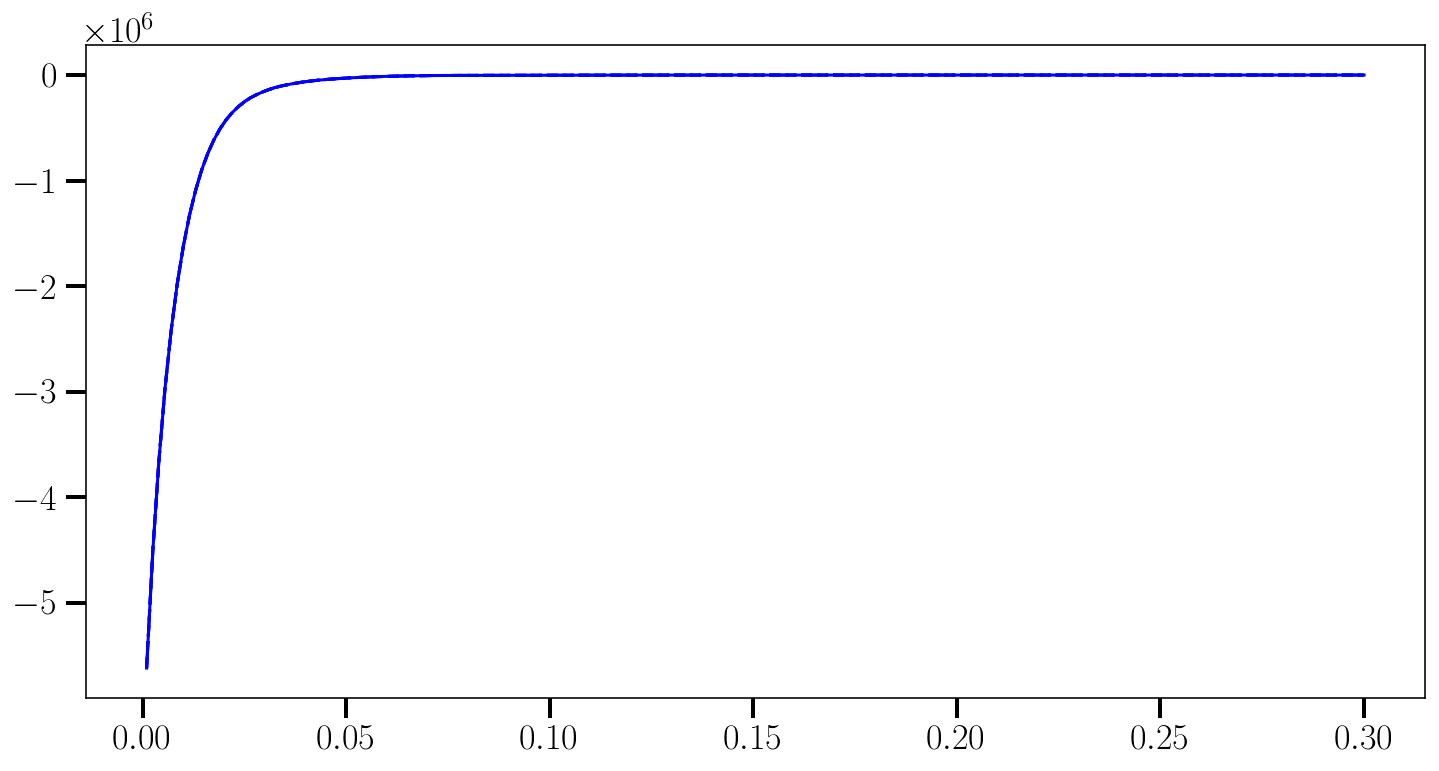

In [10]:
#zz=1.8

if False:
    k1=0.08#np.linspace(0.01,0.1)#
    k2=k1/2
    theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
elif False:#squeeze
    k1 = 0.05
    k2= 3*np.linspace(0.05,0.1)
    k3 = k2
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
else:
    k1 = k2 = k3 = np.linspace(0.001,0.3,200)
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

cosmo_functions = CosmologicalFunctions(cosmo)#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

plt.figure(figsize=(12,6))


r=0;s=0
plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='blue')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-',label='WA/RR',color='orange')
r=1;s=0
plt.plot(k3,(WA2.l0(params,r,s)),'--',label='WA',color='blue')
plt.plot(k3,(WA2_new.l0(params,r,s)),'--',label='WA',color='blue')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'--',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'--',label='WA/RR',color='orange')
r=0;s=1
plt.plot(k3,(WA2.l0(params,r,s)),'-.',label='WA',color='blue')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-.',label='RR',color='red')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-.',label='WA/RR',color='orange')
r=1/3;s=1/3
#plt.plot(k3,(WA2.l0(params,r,s)),'-',label='WA',color='black')
#plt.plot(k3,(RR2.l0(params,derivs,r,s)),'-.',label='RR',color='black')
#plt.plot(k3,(WARR.l0(params,derivs,r,s)),'-.',label='WA/RR',color='orange')



In [10]:
zz=0.5

k1 = np.linspace(0.05,0.1)
k3 = k1
k2= 0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(100,zz,k1,k2,k3)


NameError: name 'GR0PNG' is not defined

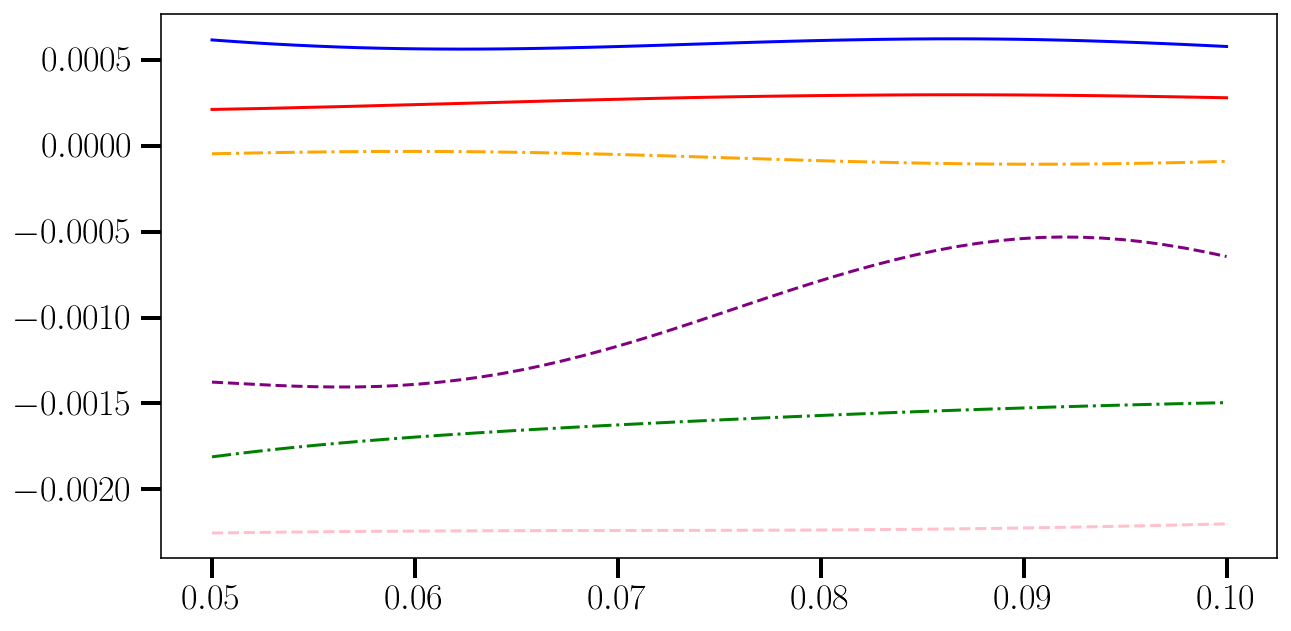

In [28]:
#so lets plot monopole...
plt.figure(figsize=(10,5))
r=0;s=0

justWS=WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)
#totalws = justwaRR+WAGR.l0(params,betas,r,s)+RRGR.l0(params,derivs,betas,r,s)
plt.plot(k3,GR2.l0(params,betas)/2/GR0.l0(params),'-.',label='GR',color='green')

plt.plot(k3,WA2.l0(params,r,s)/GR0.l0(params),'-',label='WA',color='blue')
plt.plot(k3,RR2.l0(params,derivs,r,s)/GR0.l0(params),'-',label='RR',color='red')
plt.plot(k3,WARR.l0(params,derivs,r,s)/GR0.l0(params),'-.',label='WA-RR',color='orange')

plt.plot(k3,WAGR.l0(params,betas,r,s)/GR0.l0(params),'--',label='WA-GR',color='purple')
plt.plot(k3,RRGR.l0(params,derivs,betas,r,s)/GR0.l0(params),'--',label='RR-GR',color='pink')

for i in [0.5,1.0,2.0]:
    PNGparams = cosmo_functions.get_PNGparams(i,zz,k1,k2,k3)
    plt.plot(k3,(GR0PNG.l0(params,PNGparams)-GR0.l0(params))/GR0.l0(params),'--',color='blue',alpha=0.8,label='fNL=%.1f'%i)#
    #plt.plot(k3,(GR0PNGtest.l0(params,PNGparams)-GR0.l0(params))/GR0.l0(params),'--',color='lime')

#plt.plot(k3,totalwa/GR0.l0(params),'--',color='black',label='RR+WA')
#plt.plot(k3,justwaRR/GR0.l0(params),'-',color='red',label='RR+WA')
#plt.plot(k3,total/GR0.l0(params),label='RR+WA+GR',color='black')
plt.xlabel('$ k_1=k_3 \,\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$\Delta B_{\ell=0}(k_1=k_3,k_2=0.01)|/B^N_{\ell=0}$')
#plt.plot(k3,np.zeros_like(k3),'--', color='black')
#plt.text(0.1,0.6,r"z=0.4 - DESI-like")
plt.xlim(0.05,0.10)
plt.legend(bbox_to_anchor=(0.85, 0.35, 0.5, 0.5))
plt.grid(ls='--',lw=0.75)
#plt.ylim(0,0.003)
plt.savefig('plots/second_order_lots.png', bbox_inches='tight', dpi=400)
plt.show()

In [ ]:
#test GR:
zz=1
k1 = np.linspace(0.0006,0.5,1000)
k3 = k1/2
k2= k1
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo)
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2,k3)

plt.figure(figsize=(10,6))
r=0;s=0

#totalwa = WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+RRGR.l0(params,derivs,betas,r,s)
#total = totalwa+GR2.l0(params,betas)

#plt.plot(k3,np.abs(GR2.l0(params,betas)),'-.',label='GR',color='green')
#plt.plot(k3,np.abs(WA2.l0(params,r,s)),'--',label='Wide-angle',color='blue')
plt.plot(k3,np.abs(RR2.l0(params,derivs,r,s)),'--',label='redshift derivative',color='red')
#plt.plot(k3,np.abs(WARR.l0(params,derivs,r,s)),'-.',label='Mixed',color='orange')
#plt.plot(k3,(GR0PNG.l0(params,PNGparams)-GR0.l0(params)),'--',color='grey')
#plt.plot(k3,np.abs(WAGR.l0(params,betas,r,s)),'--',label='Wide-angle',color='purple')
#plt.plot(k3,np.abs(RRGR.l0(params,derivs,betas,r,s)),'--',label='Wide-angle',color='lime')

#plt.plot(k3,np.abs(totalwa),'--',label='Total',color='black')
#plt.plot(k3,np.abs(total),label='Total',color='black')

plt.xscale('log')
plt.yscale('log')
plt.grid(ls='--',lw=0.75)
plt.legend()
plt.show()

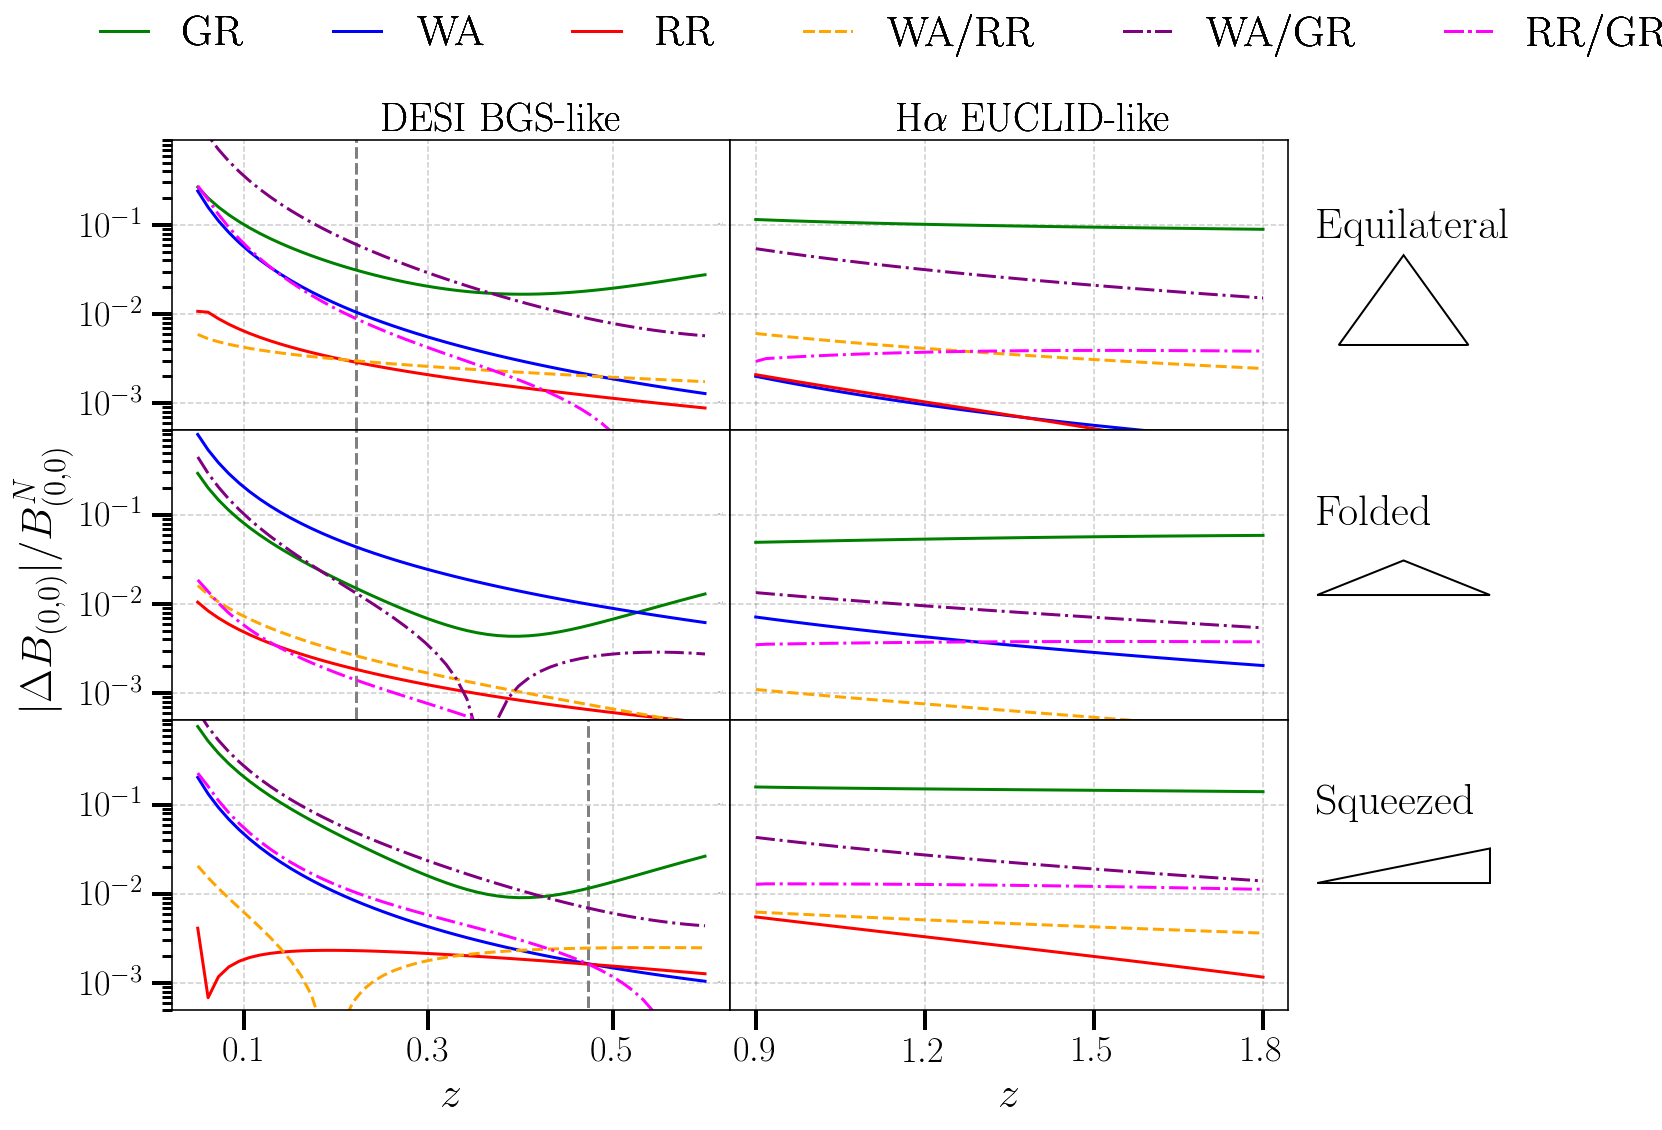

In [285]:
from matplotlib.patches import Polygon
def plot_3x2(first=True):
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

    # Create subplots with custom aspect ratios
    #axs = [fig.add_subplot(gs[0, i], aspect='10') for i in range(2)]  # Subplots in the first row

    #horizonatally
    for i in range(2):
        axs[0,i].get_xaxis().set_tick_params(which='both', size=0, labelsize=0)
        axs[1,i].get_xaxis().set_tick_params(which='both', size=0, labelsize=0)

    #vertically
    for i in range(3):
        axs[i,0].set_xticks(np.arange(0.1, 0.59, 0.2))
        axs[i,1].set_xticks(np.arange(0.9, 1.81, 0.3))

        #set triangle
        if i ==0: #
            k1 = 0.01
            k2 = k3 = k1
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
        elif i==1: # folded
            k1 = 0.02
            k2 = k3 = 0.01
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
        else: #squeezed
            k1 = k2 = 0.05
            k3 = 0.005
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

        for j in range(2):
            #choose which survey
            if j ==0:
                cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
                axs[0,j].text(0.25,1.1,'DESI BGS-like',fontsize=20)
            else:
                cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')
                axs[0,j].text(1.15,1.1,r' H$\alpha$ EUCLID-like',fontsize=20)
            z_plot = cosmo_functions.z_survey

            params = cosmo_functions.get_params(k1,k2,theta,z_plot)
            derivs = cosmo_functions.get_derivs(z_plot)
            betas = cosmo_functions.get_beta_funcs(z_plot)

            norm = GR0.l0(params)
            
            #plot different contributions
            if first:#for first order stuff
                r=1;s=0
                axs[i,j].set_ylim(1.0001e-3,.9)
                axs[i,j].plot(z_plot,np.abs(GR1.l1(params,betas)/norm),'-',label='GR',color='green')
                axs[i,j].plot(z_plot,np.abs(WA1.l1(params,r,s)/norm),'-',label='WA',color='blue')
                axs[i,j].plot(z_plot,np.abs(RR1.l1(params,derivs,r,s)/norm),'-',label='RR',color='red')
                axs[1,0].set_ylabel('$|B_{(1,0)}|/B^N_{(0,0)}$')
                axs[0,1].legend(ncol=3,frameon=False,title_fontsize=15,handlelength=1.1, handleheight=0.5, borderpad=0)

            else:#for second order stuff
                r=s=1/3
                axs[i,j].set_ylim(5e-4,.9)
                #axs[i,j].plot(z_plot,np.abs(totalwa/GR0.l0(params)),'--',label='Total',color='black')
                #axs[i,j].plot(z_plot,np.abs(total/GR0.l0(params)),label='Total',color='black')
                if i ==0 and j ==0:
                    axs[i,j].plot(z_plot,np.abs(GR2.l0(params,betas)/norm),'-',label='GR',color='green')

                    axs[i,j].plot(z_plot,np.abs(WA2.l0(params,r,s)/norm),'-',label='WA',color='blue')
                    axs[i,j].plot(z_plot,np.abs(RR2.l0(params,derivs,r,s)/norm),'-',label='RR',color='red')
                    axs[i,j].plot(z_plot,np.abs(WARR.l0(params,derivs,r,s)/norm),'--',label='WA/RR',color='orange')

                    axs[i,j].plot(z_plot,np.abs(WAGR.l0(params,betas,r,s)/norm),'-.',label='WA/GR',color='purple')
                    axs[i,j].plot(z_plot,np.abs(RRGR.l0(params,derivs,betas,r,s)/norm),'-.',label='RR/GR',color='magenta')
                else:
                    axs[i,j].plot(z_plot,np.abs(GR2.l0(params,betas)/norm),'-',color='green')

                    axs[i,j].plot(z_plot,np.abs(WA2.l0(params,r,s)/norm),'-',color='blue')
                    axs[i,j].plot(z_plot,np.abs(RR2.l0(params,derivs,r,s)/norm),'-',color='red')
                    axs[i,j].plot(z_plot,np.abs(WARR.l0(params,derivs,r,s)/norm),'--',color='orange')

                    axs[i,j].plot(z_plot,np.abs(WAGR.l0(params,betas,r,s)/norm),'-.',color='purple')
                    axs[i,j].plot(z_plot,np.abs(RRGR.l0(params,derivs,betas,r,s)/norm),'-.',color='magenta')

                axs[1,0].set_ylabel('$|\Delta B_{(0,0)}|/B^N_{(0,0)}$')
                fig.legend(loc=[0.06,0.95],ncol=6,frameon=False,title_fontsize=13,handlelength=1.1, handleheight=0.5, borderpad=0)
                #xs[0,1].legend(ncol=1,frameon=False,title_fontsize=15,handlelength=1.1, handleheight=0.5, borderpad=0)

            
            #we plot scale where it breaks down
            chi = 2*np.pi/k3
            axs[i,0].vlines(cosmo_functions.d_to_z(chi),0,1e+10,linestyles='--',color='grey',alpha=1)
            
            axs[i,j].set_yscale('log')
            
            axs[i, j].grid(ls='--', lw=0.75, color='k', alpha=0.2)
            
            axs[2,j].set_xlabel('$z$')
                        
            axs[i,1].get_yaxis().set_tick_params(which='both', size=0, labelsize=0)
            
    
    def triple_triangle_coords(base_x=0.4,base_y=0.5):
        triangle_coords = {
            0: np.array([[base_x+0.05, base_y +0.1-0.3*np.sin(np.pi/3)], [base_x+0.2, base_y+0.1], [base_x+0.35, base_y +0.1-0.3*np.sin(np.pi/3)]]),  # Equilateral triangle
            1: np.array([[base_x, base_y-0.05], [base_x+0.2, base_y+0.05], [base_x+0.4, base_y-0.05]]),  # Folded triangle
            2: np.array([[base_x, base_y-0.05], [base_x+0.4, base_y+0.05], [base_x+0.4, base_y-0.05]])   # Squeezed triangle
        }
        return triangle_coords
    
    triangle_labels = {0: 'Equilateral', 1: 'Folded', 2: 'Squeezed'}
    
    base_x,base_y = 0.4,0.5
    # Plot the triangles on the additional axis
    for i in range(3):
        
        # Create an additional axis for the triangles
        ax_triangles = fig.add_axes([0.8, 0.6-0.25*i, 0.3, 0.3], frameon=False)
        ax_triangles.set_xticks([])
        ax_triangles.set_yticks([])
    
        triangle = Polygon(triple_triangle_coords(0.4,0.5)[i], closed=True, fill=None, edgecolor='black')
        ax_triangles.add_patch(triangle)
        ax_triangles.text(base_x, base_y+0.15, triangle_labels[i])

    fig.subplots_adjust(hspace=0)
    fig.subplots_adjust(wspace=0)
    if first:
        plt.savefig('plots/redshift_first.png', bbox_inches='tight', dpi=400)
    else:
        plt.savefig('plots/redshift_second.png', bbox_inches='tight', dpi=400)

plot_3x2(False)


In [ ]:
#x3
plot_3x2(True)

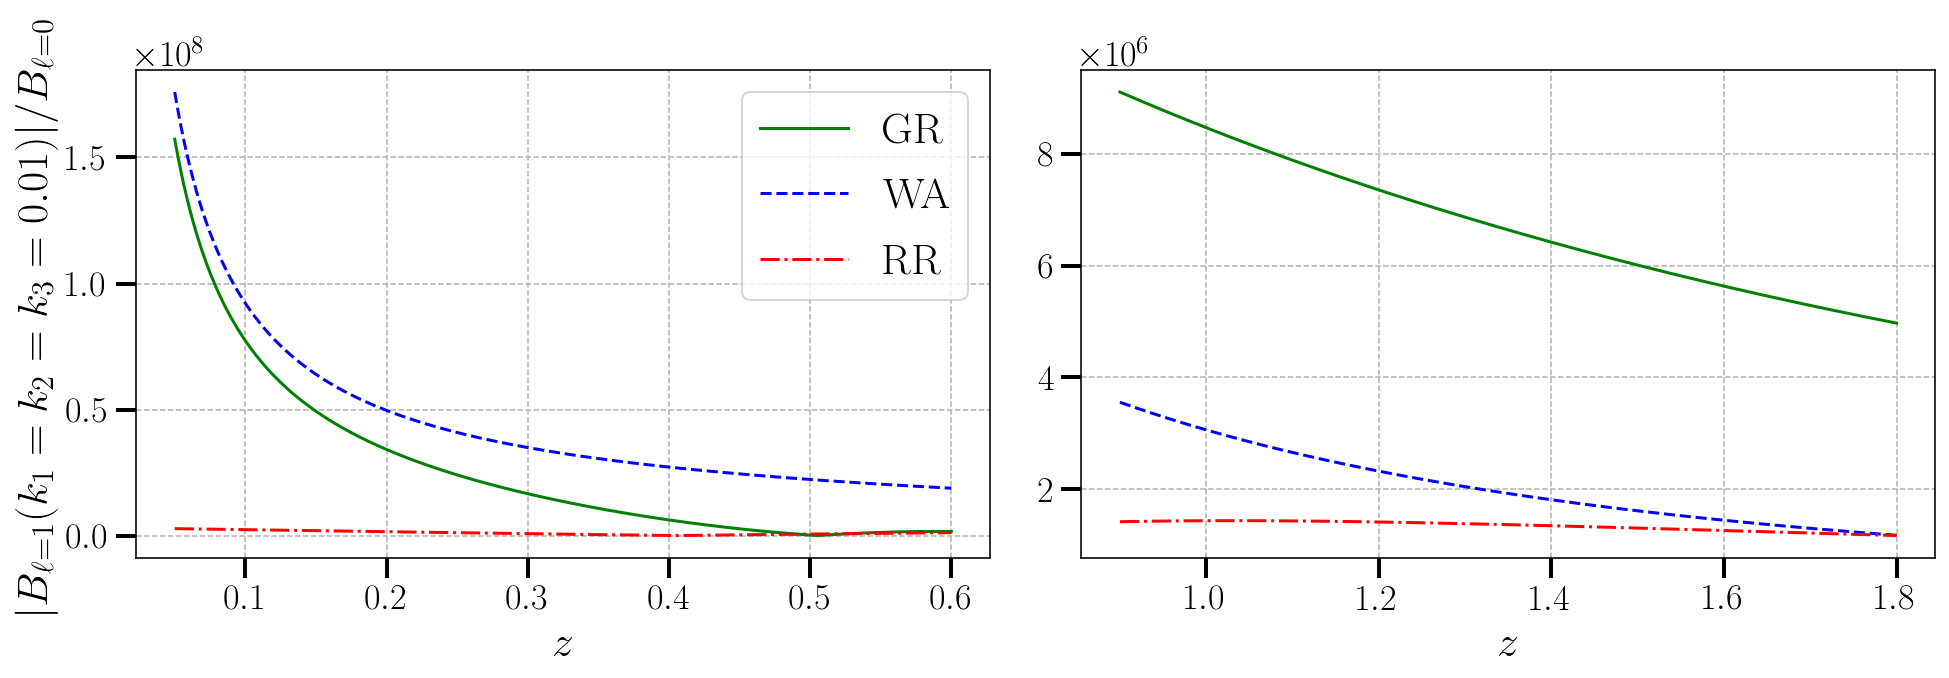

In [30]:
#plt.xlim(0,1)
z_plot = np.linspace(0.05,0.6,1000)#np.linspace(0.8,1.9,1000)#

k1 = 0.10
k2= k1
k3=0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
params = cosmo_functions.get_params(k1,k2,theta,z_plot)
derivs = cosmo_functions.get_derivs(z_plot)
betas = cosmo_functions.get_beta_funcs(z_plot)
PNGparams = cosmo_functions.get_PNGparams(1,z_plot,k1,k2,k3)

r=0;s=0

norm = C

if False:
    #totalwa = WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)
    #total = WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)+GR2.l0(params,betas)

    plt.plot(z_plot,np.abs(totalwa/GR0.l0(params)),'--',label='Total',color='black')
    plt.plot(z_plot,np.abs(total/GR0.l0(params)),label='Total',color='black')
    #plt.plot(z_plot,(WA2.l0(params,r,s)/norm),'--',label='Wide-angle',color='blue')
    #plt.plot(z_plot,(RR2.l0(params,derivs,r,s)/norm),'--',label='redshift derivative',color='red')
    #plt.plot(z_plot,(WARR.l0(params,derivs,r,s)/norm),'-.',label='Mixed',color='orange')
    #plt.plot(z_plot,np.abs(GR0PNG.l0(params,PNGparams)-GR0.l0(params))/norm,'--',color='grey')
    #plt.plot(z_plot,(WAGR.l0(params,betas,r,s)/norm),'--',label='',color='purple')
    #plt.plot(z_plot,(RRGR.l0(params,derivs,betas,r,s)/norm),'--',label='',color='lime')
    plt.legend()
    plt.grid(ls='--',lw=0.75)
    plt.xlabel('$z$')
    
else:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    for i in range(2):
        if i == 0:
            cosmo_functions = CosmologicalFunctions(cosmo,'BGS')
            z_plot = np.linspace(0.05,0.6,1000)
        else:
            cosmo_functions = CosmologicalFunctions(cosmo)
            z_plot = np.linspace(0.9,1.8,1000)#np.linspace(0.05,0.6,1000)
      
        params = cosmo_functions.get_params(k1,k2,theta,z_plot)
        derivs = cosmo_functions.get_derivs(z_plot)
        betas = cosmo_functions.get_beta_funcs(z_plot)

        axs[i].plot(z_plot,np.abs(GR1.l1(params,betas)/norm),'-',label='GR',color='green')
        axs[i].plot(z_plot,np.abs(WA1.l1(params,r,s)/norm),'--',label='WA',color='blue')
        axs[i].plot(z_plot,np.abs(RR1.l1(params,derivs,r,s)/norm),'-.',label='RR',color='red')
        axs[i].set_xlabel('$z$')
        axs[i].grid(ls='--',lw=0.75)
        #axs[i].set_yscale('log')
        
    axs[0].legend()
    axs[0].set_ylabel('$  |B_{\ell=1}(k_1=k_2= k_3=0.01)|/B_{\ell=0}$')
    plt.tight_layout()
    #plt.savefig('plots/redshift_first.png', bbox_inches='tight', dpi=400)
    
#plt.ylabel('$  B_{\ell=1}(k_1=k_2= k_3=0.01)\,\,[\mathrm{Mpc}/h]^6$')

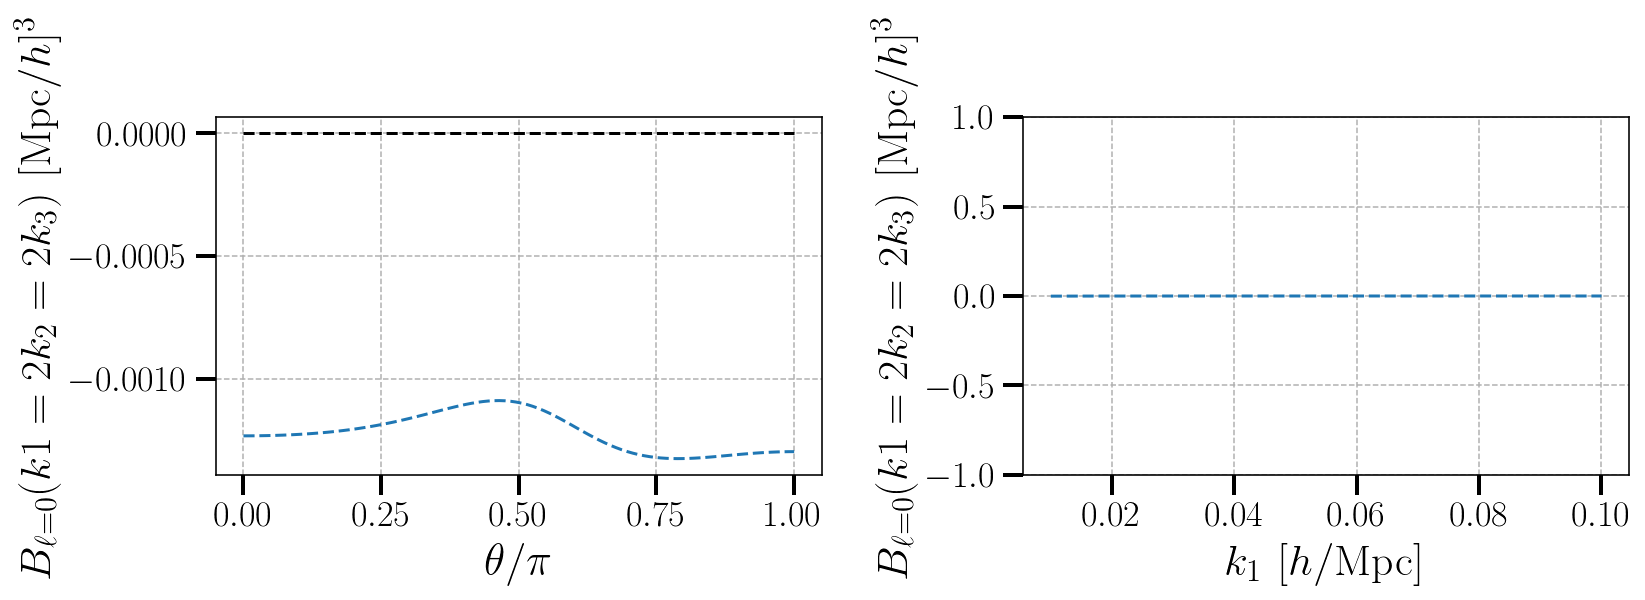

In [31]:
#for quadrupole

# Create a figure and a gridspec
fig = plt.figure(figsize=(12, 4))
gs = GridSpec(1, 2, width_ratios=[4,4])

# Create subplots using the gridspec
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])

zz=0.5;k1=0.04;k2=k1/4
theta = np.linspace(0,np.pi,100)#2*np.pi/3#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(1,z_plot,k1,k2,k3)

r=0;s=0
#comb = WA2.l2(params,r,s)+RR2.l2(params,derivs,r,s)+WARR.l2(params,derivs,r,s)

norm = GR0.l0(params)
# Plot on each subplot
#ax1.plot(theta/np.pi,WA2.l2(params,r,s)/norm)
#ax1.plot(theta/np.pi,comb/norm)
ax1.plot(theta/np.pi,GR2.l2(params,betas)/norm,'--')

ax1.set_xlabel(r'$ \theta /\pi$')
ax1.set_ylabel('$ B_{\ell=0}(k1=2 k_2=2 k_3) \,\,[\mathrm{Mpc}/h]^3$')
ax1.plot(theta/np.pi,np.zeros_like(theta),'--', color='black')
ax1.grid(ls='--',lw=0.75)


k1=np.linspace(0.01,0.1,100);k2=k1;k3=1*k1
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)


# Plot on each subplot
#ax2.plot(k1,WA2.l2(params,r,s)/norm)
ax2.plot(k1,GR2.l2(params,betas)/norm,'--')
#ax2.plot(k1,comb/norm)
ax2.set_xlabel(r'$ k_1 \,\, [h/\mathrm{Mpc}]$')
ax2.set_ylabel('$ B_{\ell=0}(k1=2 k_2=2 k_3) \,\,[\mathrm{Mpc}/h]^3$')
#ax2.plot(k1,np.zeros_like(k1),'--', color='black')
ax2.set_ylim(-1,1)
ax2.grid(ls='--',lw=0.75)

plt.tight_layout()
plt.show()

In [33]:
#for sciccimarro comparison...
zz=1
k1=0.05#np.linspace(0.01,0.1)#
k2=k1/3
theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo)#'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)


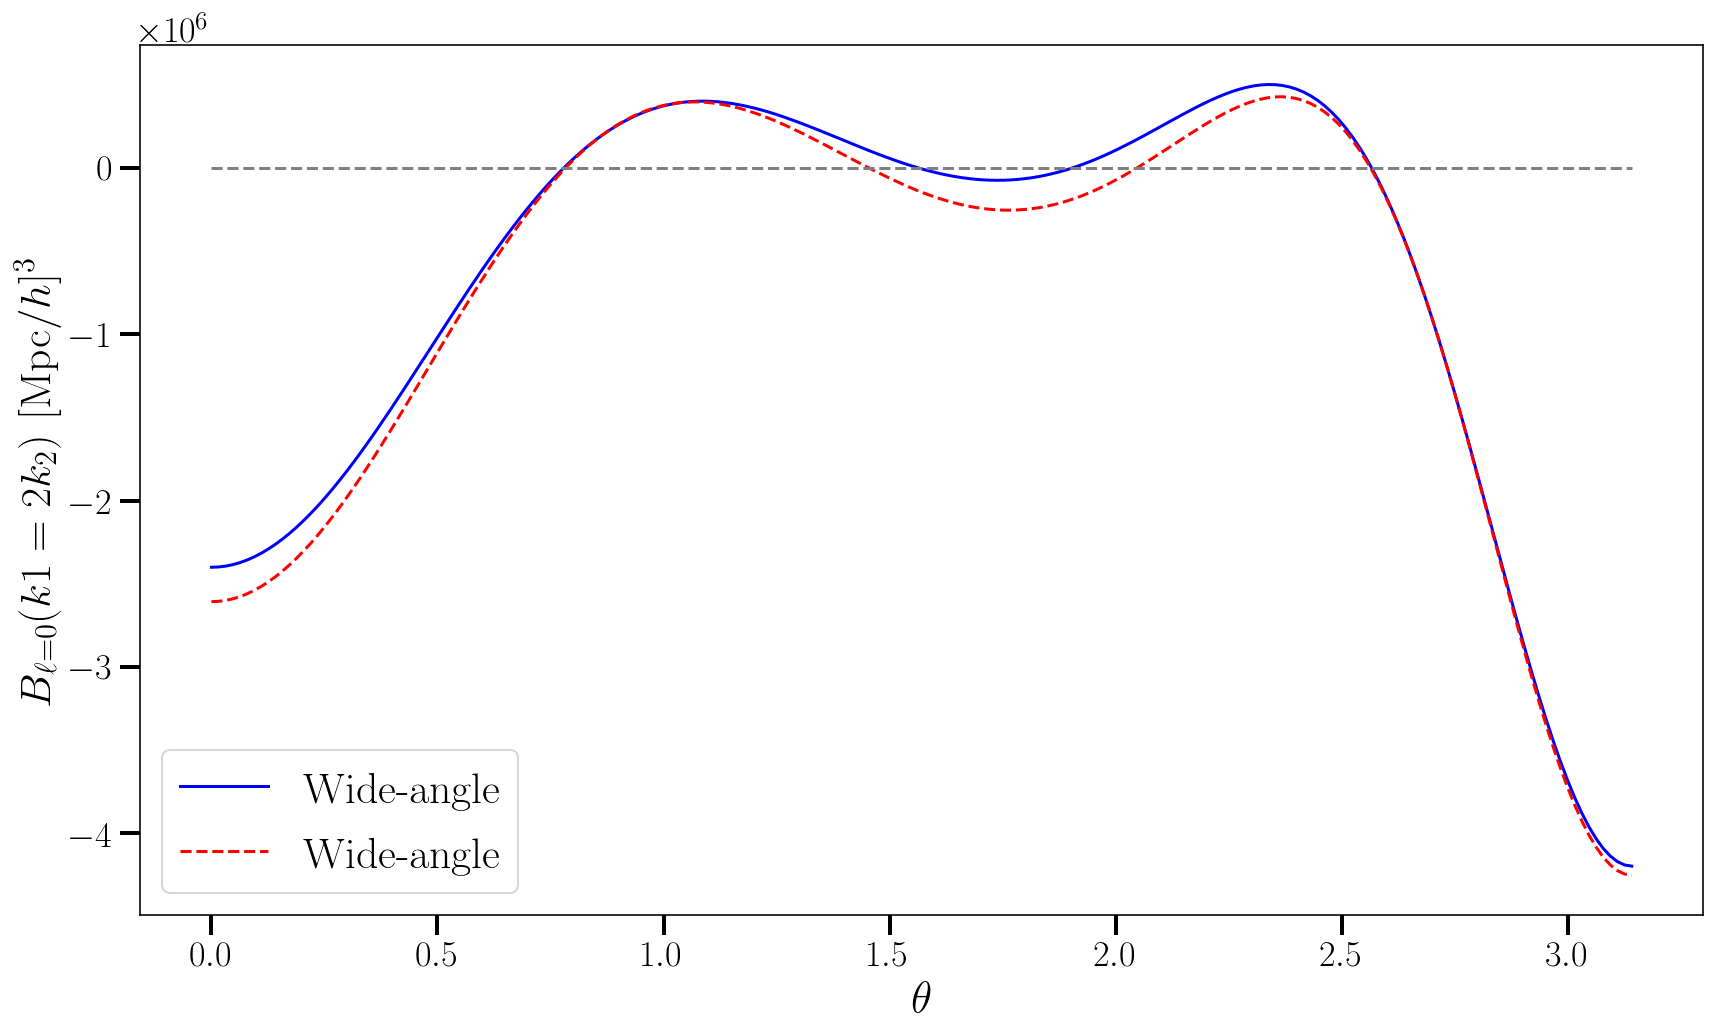

In [34]:
plt.figure(figsize=(14,8))
r=1/2;s=1/2

#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='red',label='redshift derivative')
plt.plot(theta,WA2.l0(params,r,s).real,'-',color='blue',label='Wide-angle')

plt.plot(theta,((1-r-s)*WA2.l0(params,0,0)+r*WA2.l0(params,1,0)+s*WA2.l0(params,0,1)).real,'--',color='red',label='Wide-angle')

"""
r=0;s=0
plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='red',label='redshift derivative')
plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='blue',label='Wide-angle')

r=1;s=0
plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'--',color='red',label='redshift derivative')
plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'--',color='blue',label='Wide-angle')

r=0;s=1
plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-.',color='red',label='redshift derivative')
plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-.',color='blue',label='Wide-angle')
#plt.plot(theta,GR1.l1(params,betas).imag/GR0.l0(params),'-',color='green',label='GR')
"""

#plt.plot(theta,(WA1.l1(params,r,s).imag+GR1.l1(params,betas).imag+RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='black')
plt.plot(theta,np.zeros_like(theta),'--',color='grey')
plt.xlabel(r'$ \theta $')
plt.ylabel('$ B_{\ell=0}(k1= 2 k_2) \,\,[\mathrm{Mpc}/h]^3$')
plt.legend()
#plt.xlim(1.5,2)
#plt.plot(theta,testoldder/d)
#plt.plot(theta,testold.real/(d),'-.',color='black')
#plt.plot(theta,testold.real/(d),'-.',color='grey')

In [33]:
def flat_bool(arr,slice_=None):#make flat and impose condtion k1>k2>k3
    if slice_ == None:
        return arr.flatten()[tri_bool.flatten()]
    else:
        return np.abs(arr[slice_].flatten()[tri_bool[slice_].flatten()])
#plots over all triangles     
def plot_all(ymin=1e+5,ymax=1e+10):
    zz=1
    cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)

    # define bins centres
    bin_width = 0.005
    k_bin = np.arange(bin_width,0.08,bin_width)

    k1,k2,k3 = np.meshgrid(k_bin,k_bin,k_bin,indexing='ij')

    #get theta from triagle condition - this create warnings from non-closed triangles
    # Handle cases where floating-point errors might cause cos_theta to go slightly beyond [-1, 1]
    cos_theta = (k3**2 - k1**2 - k2**2)/(2*k1*k2)
    cos_theta = np.where(np.isclose(np.abs(cos_theta), 1), np.sign(cos_theta), cos_theta) #need to get rid of rounding errors

    #if we want to suprress warnings from invalid values we can reset cos(theta) these terms are ignored anyway
    cos_theta = np.where(np.logical_or(cos_theta < -1, cos_theta > 1), 0, cos_theta)
    theta = np.arccos(cos_theta)
    
    params = cosmo_functions.get_params(k1,k2,theta,zz)

    #create bool for closed traingles with k1>k2>k3...
    tri_bool = np.full_like(k1,False).astype(np.bool_)
    fake_k = np.zeros_like(k1)# also create fake k- to plot over as in we define k1 then allow space to fill for all triangles there
    mesh_index = np.zeros_like(k1)
    tri_num = 0
    for i in range(k1.shape[0]+1):
        if i == 0:
            continue
        for j in range(i+1):#enforce k1>k2
            if j == 0:
                continue
            for k in range(i-j,j+1):# enforce k2>k3 and triangle condition |k1-k2|<k3
                if k==0:
                    continue

                #for indexing
                ii = i-1
                jj = j-1
                kk = k-1
                
                #print(ii,jj,kk)
                tri_bool[ii,jj,kk] = True
                mesh_index[ii,jj,kk] = tri_num
                tri_num +=1
                fake_k[ii,ii,ii] = 1 

    def flat_bool(arr):#make flat and impose condtion k1>k2>k3
        return np.abs(arr.flatten()[tri_bool.flatten()])

    plt.figure(figsize=(14,6))
    for i in range(len(flat_bool(fake_k))):
        if flat_bool(fake_k)[i]>0:
            plt.vlines(i+1,-1e+10,1e+10,linestyles='--',color='grey',alpha=0.6)

    def thin_xticks(arr,split=7,frac=3):#there are too many xticks at the start
        return np.concatenate((arr[:split][::frac],arr[split:]))
    
    tri_index = np.arange(len(flat_bool(k1))) 
    index_ticks = tri_index[flat_bool(fake_k)>0]+1#+1 as get where k1 steps not the equalateral before...
    ticks = k_bin
    _ = plt.xticks(thin_xticks(index_ticks)[1:], [round(i, 3) for i in thin_xticks(ticks)[1:]])
    
    plt.yscale('log')
    plt.ylim(ymin,ymax)
    plt.xlim(0,tri_index[-1])
    plt.xlabel('$k_1$ [h/Mpc]')
    
    #np.array([flat_bool(k1/bin_width),flat_bool(k2/bin_width),flat_bool(k3/bin_width)]).astype(np.int_).T
    
    #plot where k2 steps..
    for i in range(mesh_index.shape[0]):
        for j in range(mesh_index.shape[0]):
            plt.vlines(mesh_index[i,j,j]+1,0,1e+10,linestyles='--',color='grey',alpha=0.2)
    
    if False:
        #so lets find and shade squeezed limit
        is_squeeze = np.zeros_like(mesh_index)
        for i in range(mesh_index.shape[0]):
            for j in range(i+1):
                for k in range(i-j-1,j+1):
                    if k < 0:
                        continue
                    if i+1 > 3*(k+1) and j+1 > 3*(k+1):
                        is_squeeze[i,j,k] = 1e+8

        plt.fill_between(flat_bool(mesh_index), 0,1e+10, where=flat_bool(is_squeeze), color='gray', alpha=0.5)

    return params,derivs,betas,mesh_index,tri_bool

In [34]:
def plot_slice(contribution,which_slice=(10,10,10)):
    """plot triangles at correct triangle number"""
    x_tmp = mesh_index[which_slice]
    x = x_tmp[x_tmp>0]# remove triangles we are not considering 
    y = flat_bool(contribution,(which_slice))
    return x,y

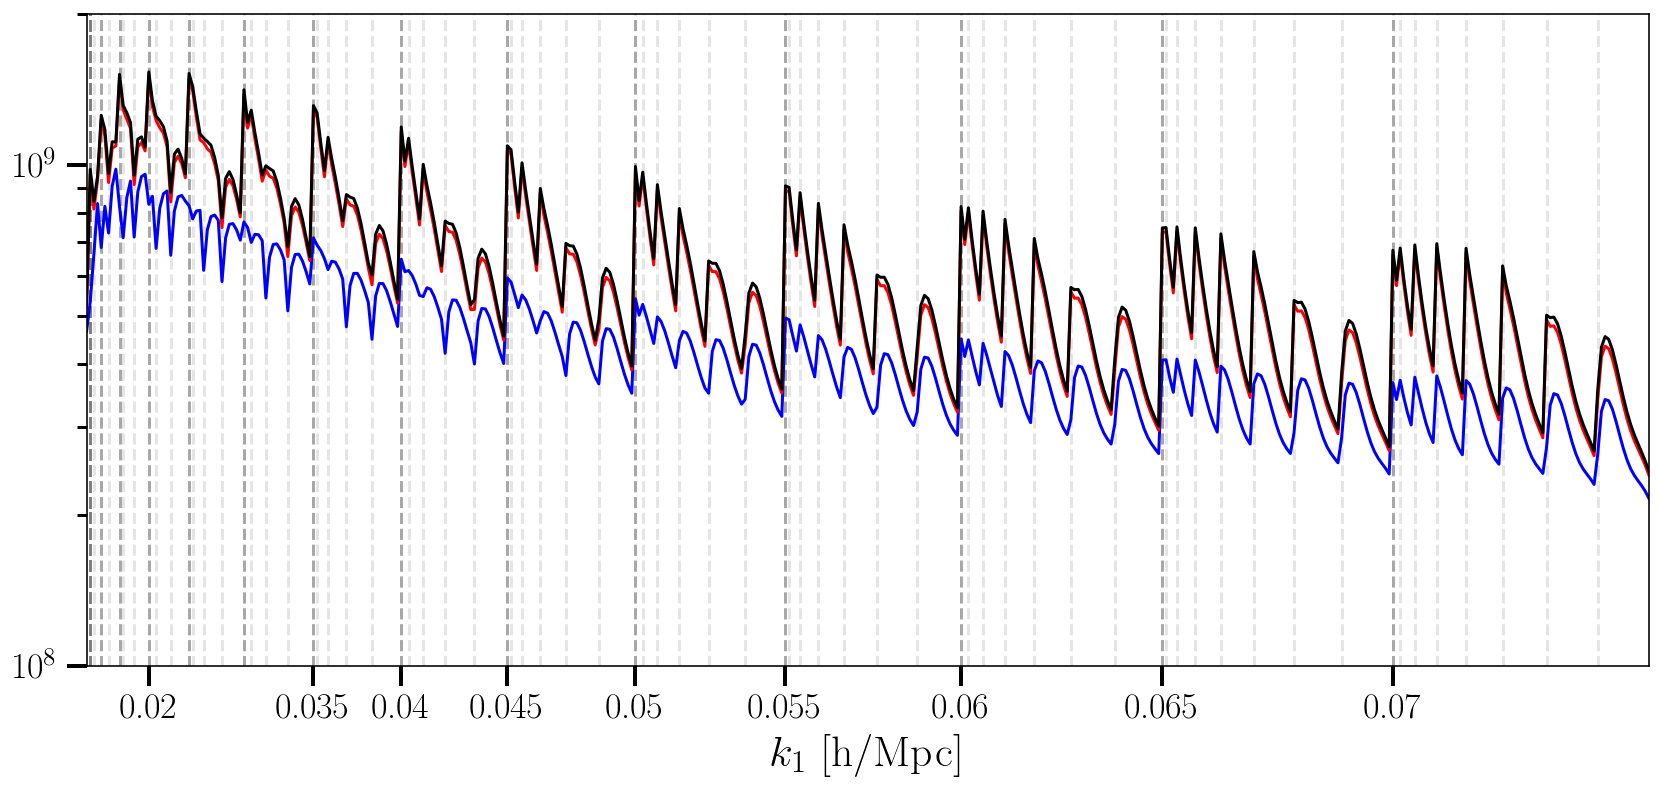

In [81]:
params,derivs,betas,mesh_index,tri_bool = plot_all(1e+8,2e+9)

#plt.plot(flat_bool(np.sqrt(COV.N11(params,1e+3,V123))),'-',label='GR',color='blue')
plt.plot(flat_bool(np.sqrt(COV1.N11(params,1e+3,V123))),'-',label='GR',color='blue')
plt.plot(flat_bool(np.sqrt(COV1.N30(params,1e+3,V123))),'-',label='GR',color='red')
plt.plot(flat_bool(np.sqrt(COV1.N10(params,1e+3,V123))),'-',label='GR',color='black')



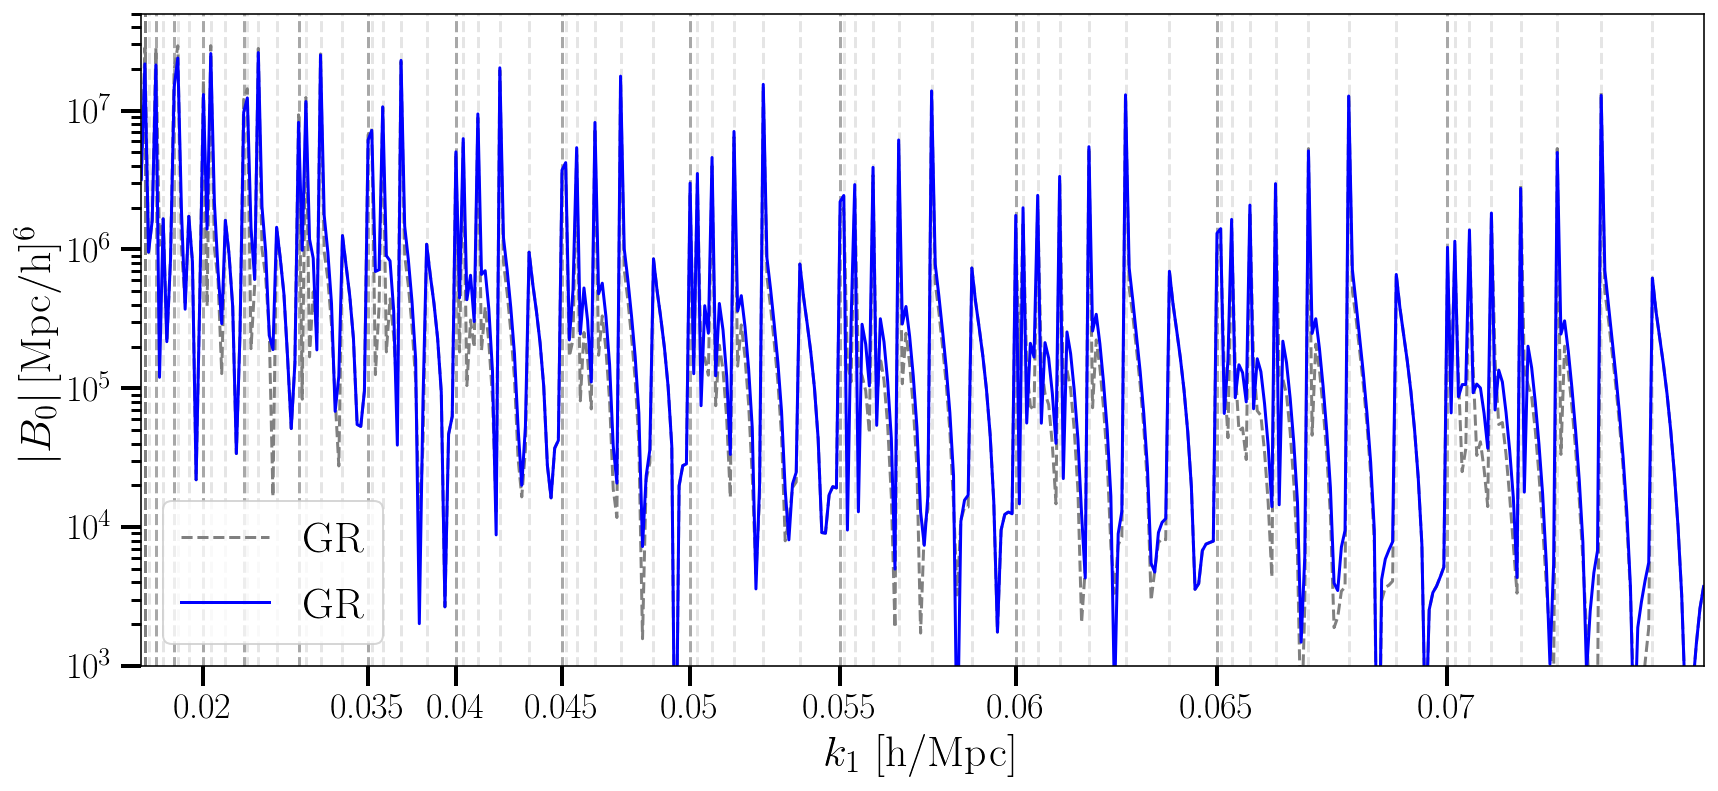

In [33]:
params,derivs,betas,mesh_index,tri_bool = plot_all(1e+3,5e+7)

#so plot actual stuff
x,y = plot_slice(GR0.l0(params),(4,3,0))
#plt.plot(x,y,'o',label='N',color='black')

#plt.plot(flat_bool(is_squeeze),'o',label='N',color='black')

r=s=1/3
#plt.plot(flat_bool(GR0.l0(params)),'-',label='N',color='black')

r=0;s=0
#plt.plot(flat_bool(WA2.l0(params,r,s)),'-',label='GR',color='blue')
r=1;s=0
plt.plot(flat_bool(WA2.l0(params,r,s)),'--',label='GR',color='grey')
r=0;s=1
plt.plot(flat_bool(WA2.l0(params,r,s)),'-',label='GR',color='blue')


#plt.plot(flat_bool(GR2.l0(params,betas)),'-',label='GR',color='green')
#WAtot = WA2.l0(params,r,s)+WAGR.l0(params,betas,r,s)
#plt.plot(flat_bool(WAtot),'-',label='WA',color='blue')
#RRtot = RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+RRGR.l0(params,derivs,betas,r,s)
#plt.plot(flat_bool(RRtot),'-',label='RR',color='red')

#plt.plot(flat_bool(WAtot+RRtot),'-',label='WS',color='black')
#plt.plot(flat_bool(RR2.l0(params,derivs,r,s)),'-',label='RR',color='red')
#plt.plot(flat_bool(WARR.l0(params,derivs,r,s)),'-',label='WARR',color='green')
#plt.plot(flat_bool(WAGR.l0(params,betas,r,s)))
#plt.plot(flat_bool(RRGR.l0(params,derivs,betas,r,s)))

plt.ylabel(r'$|B_0| \, [\rm Mpc/h]^6$')
plt.legend()
plt.savefig('plots/monopole_all.png', bbox_inches='tight', dpi=400)

In [ ]:
params,derivs,betas,mesh_index,tri_bool = plot_all(2e-1,1e+2)
r=s=1/3
#plt.plot(flat_bool(is_squeeze),'o',label='N',color='black')

r=0;s=1
plt.plot(flat_bool(RR2.l0(params,derivs,1,0)/RR2.l0(params,derivs,0,0)),'-',label='GR',color='blue')

#plt.plot(flat_bool(GR2.l0(params,betas)/GR0.l0(params)),'-',label='GR',color='green')
#WAtot = WA2.l0(params,r,s)+WAGR.l0(params,betas,r,s)
#plt.plot(flat_bool(WAtot/GR0.l0(params)),'-',label='GR',color='blue')
#RRtot = RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)+RRGR.l0(params,derivs,betas,r,s)
#plt.plot(flat_bool(RRtot/GR0.l0(params)),'-',label='GR',color='red')

#plt.plot(flat_bool((GR2.l0(params,betas)+WAtot+RRtot)/GR0.l0(params)),'-',label='WS',color='black')
plt.ylabel(r'$|\Delta B_0|/B_{N,0}$')

#plt.savefig('plots/monopole_all_norm.png', bbox_inches='tight', dpi=400)

In [ ]:
plt.plot(flat_bool((WAtot+RRtot)/GR0.l0(params))-flat_bool((WAtot)/GR0.l0(params)),'-',label='WS',color='black')
plt.xscale('log')

In [ ]:
params,derivs,betas,mesh_index,tri_bool = plot_all(1e+5,1e+10)

plt.plot(flat_bool(GR0.l0(params)),'o',label='N',color='black')
#plt.plot(160,1e+9,'o')
if False:
    plt.plot(flat_bool(GR1.l1(params,betas)),'-',label='GR',color='green')
    plt.plot(flat_bool(GR2.l0(params,betas)),'-',label='GR',color='orange')
else:
    r=s=0
    #plt.plot(flat_bool(WA1.l1(params,r,s)),'-',label='WA',color='blue')
    #plt.plot(flat_bool(WA2.l0(params,r,s)),'-',label='WA',color='orange')#plt.plot(flat_bool(R#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'-',label='RR',color='red')R2.l0(params,derivs,r,s)),'-',label='RR',color='orange')
    plt.plot(flat_bool(WA1.l1(params,r,s)+RR1.l1(params,derivs,r,s)),'o',label='1st order WS',color='forestgreen')
    r=s=1/3
    plt.plot(flat_bool(WAtot+RRtot),'-',label='2nd order WS',color='royalblue')

plt.ylabel(r'$|B_0| \, [\rm Mpc/h]^6$')
plt.legend()
plt.savefig('plots/firstandsecond.png', bbox_inches='tight', dpi=400)

Text(0, 0.5, '$|B_1| \\, [\\rm Mpc/h]^6$')

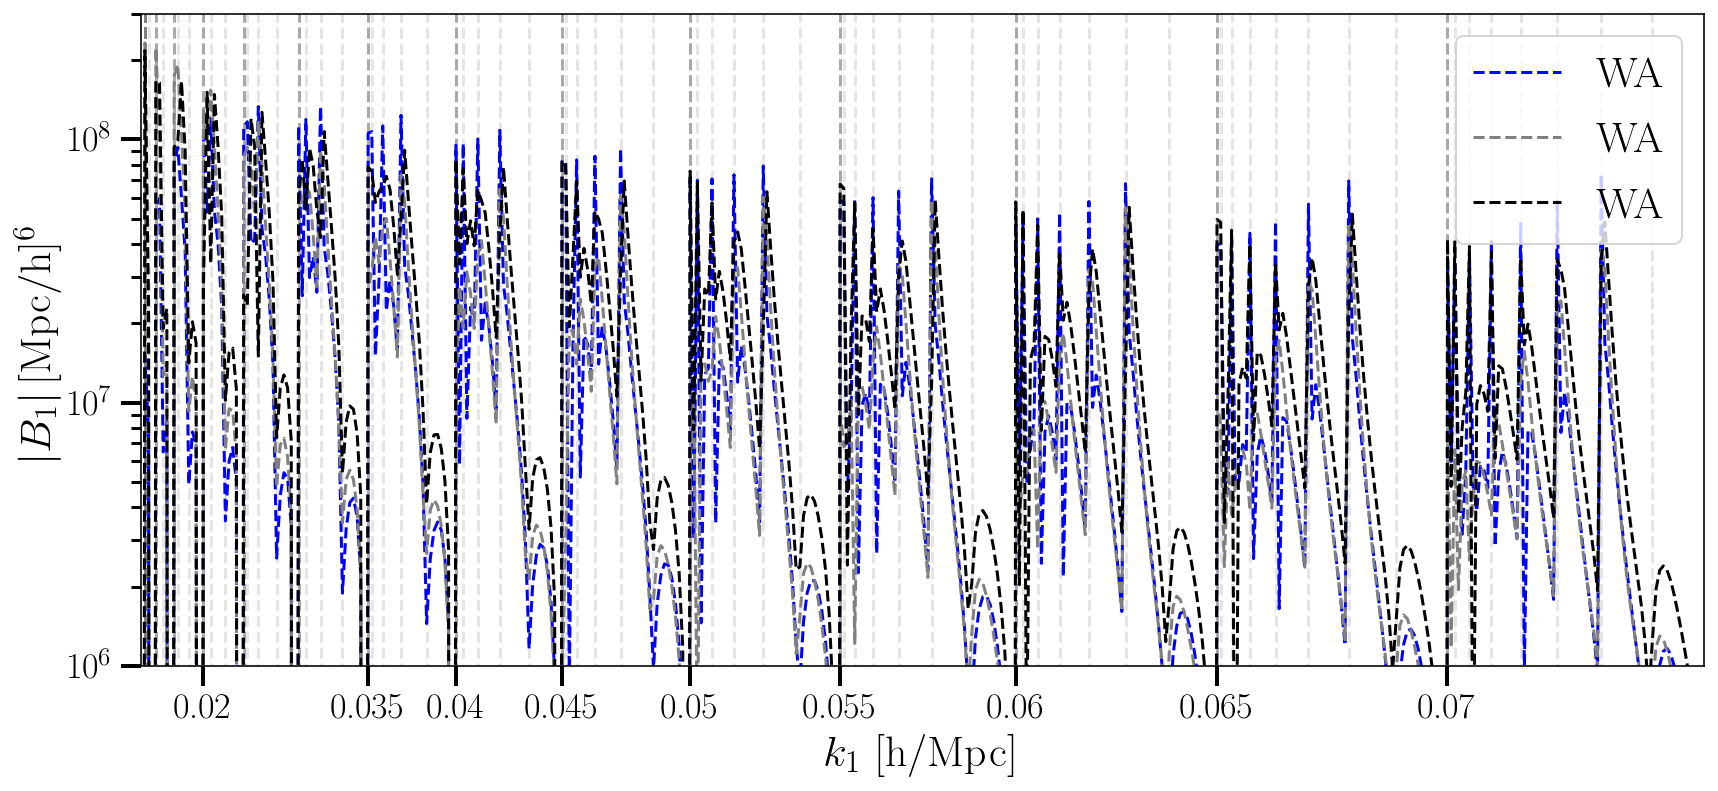

In [120]:
params,derivs,betas,all_k,tri_bool = plot_all(1e+6,3e+8)#-2e+8,2e+8
r=0;s=0
#plt.plot(flat_bool(GR1.l1(params,betas)),'-',label='GR',color='green')

#plt.plot(np.abs(flat_bool(WA1.l1(params,r,s).imag)),'-',label='WA',color='red',alpha=1)

#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'-',label='RR',color='red')
r=1/3;s=1/3
plt.plot(np.abs(flat_bool(WA1.l1(params,r,s).imag)),'--',label='WA',color='blue',alpha=1)

#plt.plot(np.abs(flat_bool(WA1test.l1(params,r,s).imag)),'--',label='WA',color='grey',alpha=1)#d.e - smaller for x1
#plt.plot(np.abs(flat_bool(WA1test1.l1(params,r,s).imag)),'--',label='WA',color='black',alpha=1)#q.e

#plt.plot(flat_bool(WA1test1.l1(params,r,s))-flat_bool(WA1test.l1(params,r,s)),'--',label='WA',color='black',alpha=1)
#plt.plot(flat_bool(RR1.l1(params,derivs,r,s).imag),'-',label='RR',color='red')
r=1;s=0
#plt.plot(flat_bool(WA1.l1(params,r,s)),'-',label='WA',color='red',alpha=1)
#plt.plot(flat_bool(WA1test.l1(params,r,s)),'--',label='WA',color='yellow',alpha=1)
#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'-',label='RR',color='black')
r=0;s=1
#plt.plot(flat_bool(WA1.l1(params,r,s)),'-',label='WA',color='red',alpha=1)
#plt.plot(flat_bool(WA1test.l1(params,r,s)),'-',label='WA',color='orange',alpha=1)
#plt.plot(flat_bool(RR1.l1(params,derivs,r,s)),'--',label='RR',color='brown')
plt.legend()
plt.ylabel(r'$|B_1| \, [\rm Mpc/h]^6$')
#plt.savefig('plots/dipole_all.png', bbox_inches='tight', dpi=400)

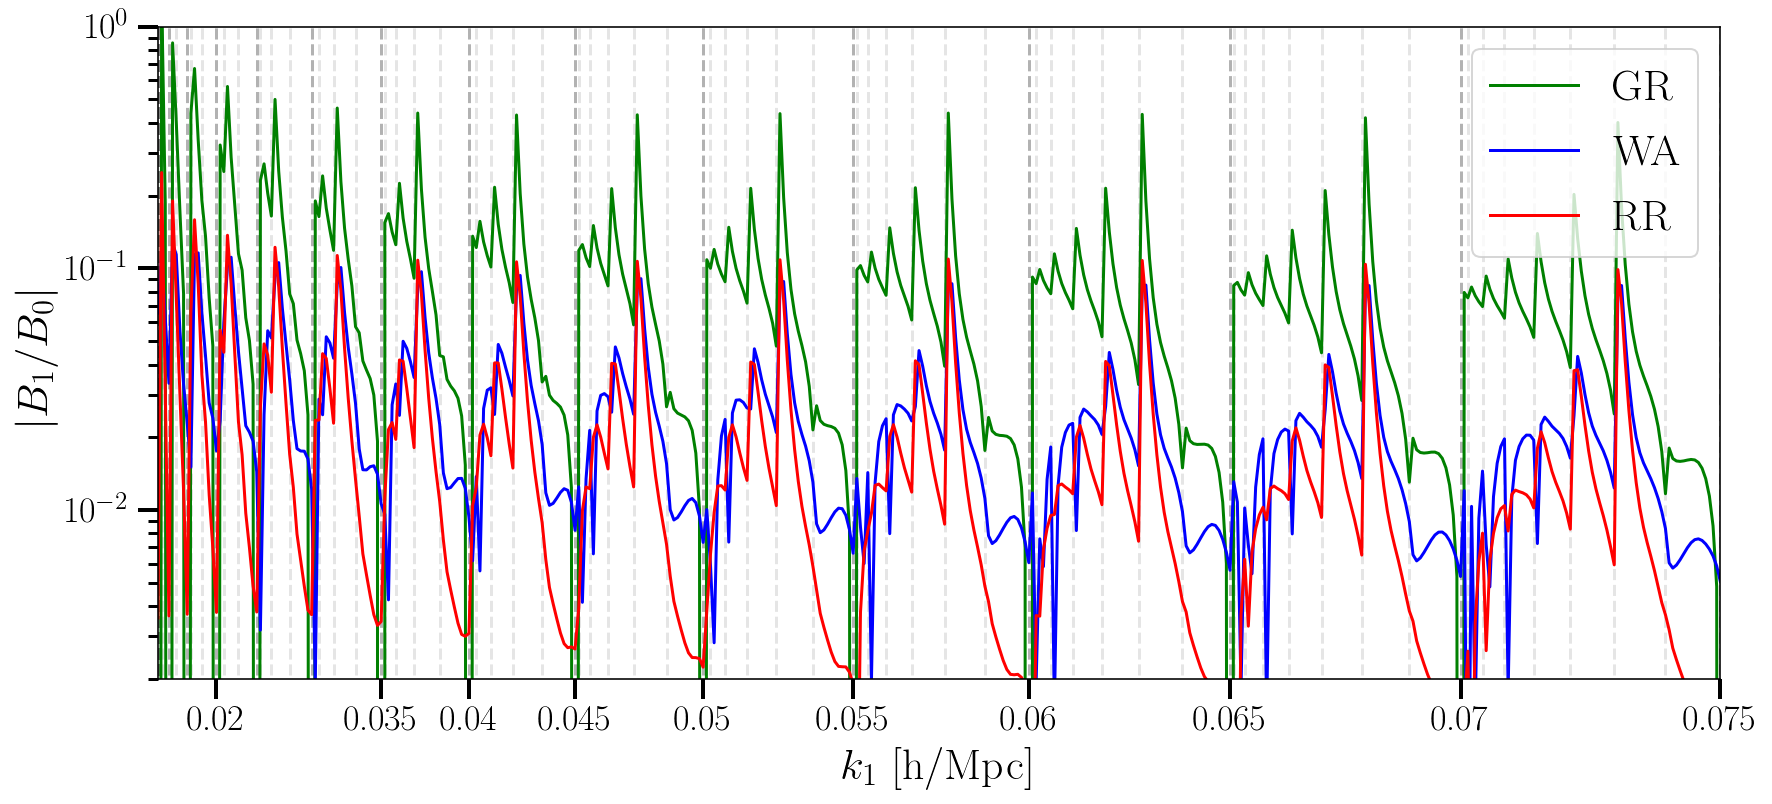

In [205]:
params,derivs,betas,all_k,tri_bool = plot_all(2e-3,1e+0)
r=0;s=0
plt.plot(flat_bool((GR1.l1(params,betas))/GR0.l0(params)),'-',label='GR',color='green')
#plt.plot(flat_bool((WA1.l1(params,r,s)+RR1.l1(params,derivs,r,s))/GR0.l0(params)),'-',label='WS',color='black')
plt.plot(flat_bool(WA1.l1(params,r,s)/GR0.l0(params)),'-',label='WA',color='blue')
plt.plot(flat_bool(RR1.l1(params,derivs,r,s)/GR0.l0(params)),'-',label='RR',color='red')
plt.legend()
plt.ylabel(r'$|B_1/B_0|$')
plt.savefig('plots/dipole_all_norm.png', bbox_inches='tight', dpi=400)

In [206]:
def plot_rs(bk,vmax=0.1,vmin=1): #plot triangle with mask!
    plt.figure(figsize=(14,6))
    # Create the colormap plot
    im = plt.imshow(np.abs(bk.T), extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(np.abs(bk[np.abs(bk)>0]).min(), vmax=np.abs(bk).max()))#,vmin=0,vmax=vmax)#
    #im = plt.imshow((bk.T), extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#
    
    cbar = plt.colorbar(im)#format='%.0e'
    cbar.set_label(r"$B_{\ell=1}(k_1=0.1,k_2,k_3)$")
    
    # Add labels and title
    plt.xlabel('$r$')
    plt.ylabel('$s$')

    #so masking 
    # Create a mask for the triangular region
    size = int(1e+3)
    r = np.linspace(0.0, 1, size,dtype=np.float32)
    s = np.linspace(0.0, 1,  size,dtype=np.float32)
    rr,ss = np.meshgrid(r,s)
    mask = np.where((rr + ss <= 1),np.nan,1)
    im = plt.imshow(mask, extent=[0, 1, 0.0, 1], interpolation='bilinear', origin='lower', cmap='binary')
    
    plt.grid(ls='--',lw=0.75,color='k',alpha=0.1)
    plt.plot(1/3,1/3,'x',markersize=10,color='black')
    x_bound = [0,1]
    y_bound = [1,0]#
    #plt.text(0.06,0.55,'$r=s=1/3$')
    plt.plot(x_bound,y_bound,'k',linewidth=3)
    # Show the plot
    plt.show()

In [207]:
def plot_rs_multi(bk,vmin,vmax): #plot triangle with mask!   
        
    fig = plt.figure(figsize=(12, 5))

    # Define gridspec with 1 rows and 3 columns
    gs = GridSpec(1, 3, width_ratios=[3, 3, 3])

    # Create subplots with custom aspect ratios
    axs = [fig.add_subplot(gs[0, i]) for i in range(3)]  # Subplots in the first row

    fig.subplots_adjust(wspace=0)
    # Create the colormap plot
    im0 = axs[0].imshow(np.abs((bk[0]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im1 = axs[1].imshow(np.abs((bk[1]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im2 = axs[2].imshow(np.abs((bk[2]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#

    #im0 = axs[0].imshow(((bk[0]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im1 = axs[1].imshow(((bk[1]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im2 = axs[2].imshow(((bk[2]).T),aspect=1, extent=[0, 1, 0, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.81, 0.25, 0.02, 0.5])
    cbar = fig.colorbar(im2, cax=cbar_ax,ticks=[0.01, 0.1, 1])
    #cbar.set_label(r"$ |B^{\rm wa}_{\ell=1}(k_1=0.05)|/B^{\rm pp}_{\ell=0}$")#"$ |B_{\ell=1}(k_1=0.05)|/B_0 $"
    cbar.set_label(r"$ |B^{\rm WA_2}_{(0,0)}|/B^{\rm N}_{(0,0)}$")#"$ |B_{\ell=1}(k_1=0.05)|/B_0 $"
    
    x_bound = [0,1]
    y_bound = [1,0]
    
    def triple_triangle_coords(base_x=0.4,base_y=0.5):
        triangle_coords = {
            0: np.array([[base_x+0.05, base_y +0.1-0.3*np.sin(np.pi/3)], [base_x+0.2, base_y+0.1], [base_x+0.35, base_y +0.1-0.3*np.sin(np.pi/3)]]),  # Equilateral triangle
            1: np.array([[base_x, base_y-0.05], [base_x+0.2, base_y+0.05], [base_x+0.4, base_y-0.05]]),  # Folded triangle
            2: np.array([[base_x, base_y-0.05], [base_x+0.4, base_y+0.05], [base_x+0.4, base_y-0.05]])   # Squeezed triangle
        }
        return triangle_coords
    
    triangle_labels = {0: 'Equilateral', 1: 'Folded', 2: 'Squeezed'}
    
    base_x,base_y = 0.55,0.85
    # Plot the triangles on the additional axis
    for i in range(3):
        triangle = Polygon(triple_triangle_coords(base_x,base_y)[i], closed=True, fill=None, edgecolor='black')
        axs[i].add_patch(triangle)
        #axs[i].text(base_x-0.1, base_y+0.15, triangle_labels[i])
       
    
    axs[0].set_ylabel('$s$')
    for i in range(3):
        
        axs[i].plot(x_bound,y_bound,'k',linewidth=3)
        #axs[i].text(0.08,0.55,r'$\boldsymbol{d}=\boldsymbol{x}_%d$'%(i+1),fontsize=20)
        axs[i].set_xlabel('$r$')
        axs[i].set_xticks(np.arange(0.2, 0.8, 0.2))
        axs[i].plot(1/3,1/3,'x',markersize=10,color='black')
        #axs[i].set_box_aspect(aspect=0.8)
        #axs[i].set_xlim(0,1)
        #axs[i].set_ylim(0.5,1)
        #axs[i].grid(ls='--',lw=0.75,color='k',alpha=0.1)
        
        if i!=0:
            axs[i].yaxis.set_major_locator(plt.NullLocator())
            
    axs[0].set_yticks(np.arange(0, 1.01, 0.2))
    # Show the plot
    plt.savefig('plots/rs_tri.png', bbox_inches='tight', dpi=400)
    plt.show()

In [ ]:
#bk_rs_WA2 = np.zeros((3,500,500))
#bk_rs_RR2 = np.zeros((3,500,500))
#bk_rs_RRGR = np.zeros((3,500,500))
bk_rs_WARR = np.zeros((3,500,500))
#bk_mono = np.zeros(3)

In [1715]:
#lets plot as a function of r and s
def rs_plot(r, s, zz):
    """Get array of"""
    bk = np.zeros((len(r),len(s)))
    
    #set triangle
    if type_tri ==0: #equilateral
        k1 = 0.01
        k2 = k3 = k1
        theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    elif type_tri==1: # folded
        k1 = 0.02
        k3 = k2 = k1/2
        theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    else: #squeezed
        k1 = k2 = 0.05
        k3 = 0.005
        theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    
    cosmo_functions = CosmologicalFunctions(cosmo)
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)
    params = cosmo_functions.get_params(k1,k2,theta,zz)
    
    bk_mono = GR0.l0(params)
    print(bk_mono)
    rr,ss = np.meshgrid(r,s,indexing='ij')
    if False:
        bk_temp = RR1.l1(params,derivs, rr, ss).imag
        #bk_temp = WA1.l1(params, rr, ss).imag
    else:
        #bk_temp = RR2.l0(params,derivs, rr, ss)
        #bk_temp = WAGR.l0(params,betas, rr, ss)
        bk_temp = WARR.l0(params,derivs, rr, ss)
        #bk_temp = WA2.l0(params, rr, ss)

    which_rs = (rr + ss <= 1)#restrict to r+s \leq 1
    return np.where(which_rs,bk_temp,0),bk_mono

r = np.linspace(0, 1, 500)
s = np.linspace(0, 1, 500)

for type_tri in range(3):
    #bk_rs_RR2[type_tri],bk_mono[type_tri] = rs_plot(r, s, 1)
    bk_rs_WARR[type_tri],bk_mono[type_tri] = rs_plot(r, s, 1)
    #bk_rs_WA2[type_tri],bk_mono[type_tri] = rs_plot(r, s, 1)

In [1726]:
plot_rs_multi(bk_rs_WAGR,1e+6,1e+8)#this is interesting

In [1719]:
plot_rs_multi(bk_rs_WARR/bk_mono[:,np.newaxis,np.newaxis],5e-3,1e-2)#this is interesting
#plot_rs_multi(bk_rs_RRGR/bk_mono[:,np.newaxis,np.newaxis],5e-4,1e-2)#this is interesting
#plot_rs_multi(bk_rs_WAGR/bk_mono[:,np.newaxis,np.newaxis],1e-3,5e-2)#this is interesting

In [1709]:
#plot_rs_multi((bk_rs_WA1)/bk_mono[:,np.newaxis,np.newaxis],1e-3,1e-1)

#plot_rs_multi(bk_rs_RR1/bk_mono[:,np.newaxis,np.newaxis],1e-3,1e-1)
#plot_rs_multi((bk_rs_WA1+bk_rs_RR1)/bk_mono[:,np.newaxis,np.newaxis],1e-3,1e-1)

plot_rs_multi(bk_rs_WA2/bk_mono[:,np.newaxis,np.newaxis],1e-3,7e-3)
plot_rs_multi(bk_rs_RR2/bk_mono[:,np.newaxis,np.newaxis],2e-4,5e-3)

In [662]:
#plot_rs((bk_rs_WA1+bk_rs_RR1)[1]/bk_mono[1])
#plot_rs((bk_rs_WA1+bk_rs_RR1)[1]/bk_mono[1])
#plot_rs((bk_rs_WA1+bk_rs_RR1)[1]/bk_mono[1])

plot_rs(bk_rs_RR2[0]/bk_mono[0])#,2e+7,vmin=8e+6)
plot_rs(bk_rs_RR2[1]/bk_mono[1])
plot_rs(bk_rs_RR2[2]/bk_mono[2])
#plot_rs(bk_rs_RR1,1e+7,vmin=1e+5)

In [102]:
#bk_0 = {}
#bk_1 = {}
#bk_2 = {}
bk_wa ={}#for x1,x2,x3 plot

In [426]:
bk_png = {}

In [138]:
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", message="invalid value encountered in divide")#hack
warnings.filterwarnings("ignore", message="invalid value encountered in arccos")

# Define the function
#@jit
def triangle_plot(x, y, zz,r=0,s=0):
    """Get array of"""
    bk_temp = np.zeros((len(x),len(y)))
    
    cosmo_functions = CosmologicalFunctions(cosmo)
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)

    xx,yy = np.meshgrid(x,y,indexing='ij')#create meshgrid where xx= k3/k1, yy= k2/k1
    
    #array version:
    k1 = 0.05 
    k3 = xx*k1
    k2 = yy*k1
    #get theta from triagle condition - this create warnings from non-closed triangles
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    
    params = cosmo_functions.get_params(k1,k2,theta,zz)
    
    #bk_temp = RR1.l1(params,derivs, r, s).imag
    bk_temp = WA1.l1(params, r, s).imag
    #bk_temp = GR1.l1(params,betas).imag
    #bk_temp = GR0.l0(params).real
    
    #bk_temp = WA2.l0(params, r, s).real
    #bk_temp = WARR.l0(params,derivs, r, s).real
    #bk_temp = WAGR.l0(params,betas, r, s).real
    #bk_temp = RR2.l0(params,derivs, r, s).real
    #bk_temp = RRGR.l0(params,derivs,betas, r, s).real
    #bk_temp = GR2.l0(params,betas).real
    if False:
        PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2_,k3)
        bk[i][which_k2] = GR0PNG.l0(params,PNGparams).real
        
    which_k2 = np.logical_and((yy > 1 - xx), (yy>xx))#restrict to closed triangles
    
    print("done")
    return np.where(which_k2,bk_temp,0)#bk_temp#

xx = np.linspace(0.01, 1, 500)
yy = np.linspace(0.495, 1, 500)

zz=1.0
if False:
    r=0;s=0
    key = "z=%.2f, r=%d, s=%d"% (zz, r, s)#so lets get key 
    bk_wa[key] = triangle_plot(xx,yy,zz,r,s)
    r=1;s=0
    key = "z=%.2f, r=%d, s=%d"% (zz, r, s)
    bk_wa[key] = triangle_plot(xx,yy,zz,r,s)
    r=0;s=1
    key = "z=%.2f, r=%d, s=%d"% (zz, r, s)
    bk_wa[key] = triangle_plot(xx,yy,zz,r,s)

else:
    r=0;s=0
    mono_key = "z=%.2f"% (zz)
    #bk_0[mono_key] = triangle_plot(xx,yy,zz,r,s)
    key = mono_key + "_WA"
    bk_1[key] = triangle_plot(xx,yy,zz,r,s)
    #k2_mesh = triangle_plot(xx,yy,zz,r,s)
    #bk_png[mono_key] = triangle_plot(xx,yy,zz,r,s)

In [62]:
print(bk_1.keys())

In [165]:
def plot_triangle(bk,vmax=1,vmin=1): #plot triangle with mask!
    plt.figure(figsize=(12,4))
    # Create the colormap plot
    im = plt.imshow(np.abs(bk.T), extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(1e-2*np.max(np.abs(bk)[np.abs(bk)>0]), vmax=np.max(np.abs(bk))))#,vmin=0,vmax=vmax)#
    #im = plt.imshow((bk.T), extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#
    
    cbar = plt.colorbar(im)#format='%.0e'
    cbar.set_label(r"$B_{\ell=1}(k_1=0.1,k_2,k_3)$")#P_{HI}(k1=0.05, \mu_1)P_{HI}(k2, \mu_2)P_{HI}(k3, \mu_3)B_{\text{Gravitational}(k1=0.05)}

    # Add labels and title
    plt.xlabel('$k_3/k_1$')
    plt.ylabel('$k_2/k_1$')

    #so masking 
    # Create a mask for the triangular region
    size = int(1e+3)
    x = np.linspace(0.0, 1, size,dtype=np.float32)
    y = np.linspace(0.5, 1,  size,dtype=np.float32)
    xx,yy = np.meshgrid(x,y)
    mask = np.where(np.logical_and((yy > 1 - xx), (yy>xx)),np.nan,1)
    #im = plt.imshow(mask, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='binary')
    
    plt.grid(ls='--',lw=0.75,color='k',alpha=0.1)
    
    x_bound = [0,0.4965,1]
    y_bound = [1,0.50,1]#
    #plt.text(0.06,0.55,'$r=s=1/3$')
    plt.plot(x_bound,y_bound,'k',linewidth=3)
    plt.show()

In [169]:
#plot_triangle(bk_0['z=1.00'],1e+10,1e+8)
plot_triangle(k2_mesh*k3_mesh*bk_1['z=1.00_WA'],1e+5,1e+3)
plot_triangle(k2_mesh*k3_mesh*bk_1['z=1.00_RR'],1e+5,1e+3)
plot_triangle(k2_mesh*k3_mesh*bk_1['z=1.00_GR'],1e+6,1e+5)
plot_triangle(k2_mesh*k3_mesh,1e+6,1e+5)


#plot_triangle(bk_wa['z=1.00, r=0, s=0']/bk_0['z=1.00'],0.1,1e-3)#d = x1
#plot_triangle(bk_wa['z=1.00, r=1, s=0']/bk_0['z=1.00'],0.1,1e-3)
#plot_triangle(bk_wa['z=1.00, r=0, s=1']/bk_0['z=1.00'],0.1,1e-3)
#plot_triangle(bk_rr1['z=1.00, r=0, s=0']/bk_0['z=1.00'],1,1e-3)
#plot_triangle((bk_png['z=1.00']-bk_0['z=1.00'])/bk_0['z=1.00'],1e-2,5e-4)

In [75]:
def plot_triangle_multi(bk0,bk1,bk2,vmax,vmin=5e-3): #plot triangle with mask!   
        
    fig = plt.figure(figsize=(12, 5))

    # Define gridspec with 1 rows and 3 columns
    gs = GridSpec(1, 3)

    # Create subplots with custom aspect ratios
    axs = [fig.add_subplot(gs[0, i]) for i in range(3)]  # Subplots in the first row

    #fig, axs = plt.subplots(1, 3,figsize=(14,5),sharey=True)
    fig.subplots_adjust(wspace=0)
    # Create the colormap plot
    im0 = axs[0].imshow(np.abs((bk0).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im1 = axs[1].imshow(np.abs((bk1).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    im2 = axs[2].imshow(np.abs((bk2).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#

    #im0 = axs[0].imshow(((bk0).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im1 = axs[1].imshow(((bk1).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im2 = axs[2].imshow(((bk2).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#

    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.81, 0.3, 0.01, 0.4])
    cbar = fig.colorbar(im2, cax=cbar_ax,ticks=[0.01, 0.1, 1])
    cbar.set_label(r"$ |B_{(1,0)}(k_1=0.05)|/B^{\rm N}_{\ell=0}$")
    x_bound = [0,0.4965,1]
    y_bound = [1,0.50,1]#

    for i in range(3):
        
        axs[i].plot(x_bound,y_bound,'k',linewidth=3)
        #axs[i].text(0.08,0.55,r'$\boldsymbol{d}=\boldsymbol{x}_%d$'%(i+1),fontsize=20)
        axs[i].set_xlabel('$k_3/k_1$')
        axs[i].set_xticks(np.arange(0.1, 0.91, 0.2))
        
        if i!=0:
            axs[i].yaxis.set_major_locator(plt.NullLocator())
            
    """       
    def triple_triangle_coords(base_x=0.4,base_y=0.5):
        triangle_coords = {
            0: np.array([[base_x+0.05, base_y +0.1-0.3*np.sin(np.pi/3)], [base_x+0.2, base_y+0.1], [base_x+0.35, base_y +0.1-0.3*np.sin(np.pi/3)]]),  # Equilateral triangle
            1: np.array([[base_x, base_y-0.05], [base_x+0.2, base_y+0.05], [base_x+0.4, base_y-0.05]]),  # Folded triangle
            2: np.array([[base_x, base_y-0.05], [base_x+0.4, base_y+0.05], [base_x+0.4, base_y-0.05]])   # Squeezed triangle
        }
        return triangle_coords
    
    triangle_labels = {0: 'Equilateral', 1: 'Folded', 2: 'Squeezed'}
    
    pos_x = [0.8,0.4,0.4]
    pos_y = [0.8,0.4,0.4]
    # Plot the triangles on the additional axis
    for i in range(1):
        
        triangle = Polygon(triple_triangle_coords(pos_x[i],pos_y[i])[i], closed=True, fill=None, edgecolor='black')
        axs[0].add_patch(triangle)
        #axs[i].text(base_x-0.1, base_y+0.15, triangle_labels[i])
    """         
    axs[0].text(0.08,0.55,'WA',fontsize=20)
    axs[1].text(0.08,0.55,'RR',fontsize=20)
    axs[2].text(0.08,0.55,'GR',fontsize=20)
    
    # Show the plot
    plt.savefig('plots/endpoint_triangles.png', bbox_inches='tight', dpi=400)
    plt.show()

In [135]:
#plot_triangle_multi(bk_0['z=1.00'],bk_0['z=1.00'],bk_0['z=1.00'],5e+9,1e+8)#newtonain
#plot_triangle_multi(bk_1['z=1.00_WA'],bk_1['z=1.00_RR'],bk_1['z=1.00_GR'],1e+8,1e+6)#corections
plot_triangle_multi(bk_1['z=1.00_WA']/bk_0['z=1.00'],bk_1['z=1.00_RR']/bk_0['z=1.00'],bk_1['z=1.00_GR']/bk_0['z=1.00'],3e-1,1e-2)#ratio

In [109]:
plot_triangle_multi(bk_wa['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_wa['z=1.00, r=0, s=1']/bk_0['z=1.00'],bk_wa['z=1.00, r=0, s=0']/bk_0['z=1.00'],0.1)
#plot_triangle_multi(bk_rr1['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_rr1['z=1.00, r=0, s=1']/bk_0['z=1.00'],bk_rr1['z=1.00, r=0, s=0']/bk_0['z=1.00'],0.2)

In [ ]:
plot_triangle_multi(bk_rr2['z=0.50, r=0, s=0']/bk_0['z=0.50'],bk_rr2['z=0.50, r=1, s=0']/bk_0['z=0.50'],bk_rr2['z=0.50, r=0, s=1']/bk_0['z=0.50'],0.25)

In [1187]:
#so what about a trriangle plots for cross terms at second order....
def plot_multi2(bk0,bk1,bk2,bk3,bk4,bk5,vmax,vmin=5e-3): #plot triangle with mask!   
        
    fig = plt.figure(figsize=(10, 5))

    # Define gridspec with 3 rows and 3 columns
    gs = GridSpec(3, 3)
    
    # Create subplots with custom aspect ratios
    axs = []
    for i in range(3):
        for j in range(i+1):
            ax = fig.add_subplot(gs[i, j])
            axs.append(ax)
        
    for i, ax in enumerate(axs):
        aspect =1
        if i == 0:
            im = ax.imshow(np.abs(bk0.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 1:
            im = ax.imshow(np.abs(bk1.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 2:
            im = ax.imshow(np.abs(bk2.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 3:
            im = ax.imshow(np.abs(bk3.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        elif i == 4:
            im = ax.imshow(np.abs(bk4.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))
        else:
            im = ax.imshow(np.abs(bk5.T), aspect=aspect, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral', norm=mpl.colors.LogNorm(vmin, vmax))

        ax.plot([0,0.4965,1], [1,0.5,1], color='black', linewidth=3)  # Plotting the triangle boundary

        if i in [0,1,3]:
            ax.set_ylabel('$k_2/k_1$')
    
        if i in [3,4,5]:
            ax.set_xlabel('$k_3/k_1$')

        ax.set_xticks(np.arange(0.1, 1.1, 0.2))
        ax.set_yticks(np.arange(0.5, 1.0, 0.3))
        ax.set_xlim(0, 1)
        ax.set_ylim(0.5, 1)
    
    #add row labels
    axs[0].text(-0.3, 0.5, 'WA', ha='right', va='center', rotation='vertical', transform=axs[0].transAxes,fontsize=20)
    axs[1].text(-0.3, 0.5, 'RR', ha='right', va='center', rotation='vertical', transform=axs[1].transAxes,fontsize=20)
    axs[3].text(-0.3, 0.5, 'GR', ha='right', va='center', rotation='vertical', transform=axs[3].transAxes,fontsize=20)
    
    # Add column labels
    axs[0].text(0.5, 1.08, 'WA', ha='center', va='bottom', transform=axs[0].transAxes,fontsize=20)
    axs[2].text(0.5, 1.08, 'RR', ha='center', va='bottom', transform=axs[2].transAxes,fontsize=20)
    axs[5].text(0.5, 1.08, 'GR', ha='center', va='bottom', transform=axs[5].transAxes,fontsize=20)
    
    left = 0.05
    right = 0.95
    bottom = +0.1
    top = 0.95
    wspace = 0
    hspace = 0
    plt.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)#

    for i in [2,4,5]:
        axs[i].yaxis.set_major_locator(plt.NullLocator())
    cbar_ax = fig.add_axes([0.91, 0.1, 0.02, 0.85])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0.001,0.01, 0.1, 1])
    cbar.set_label(r"$ |B_{(1,0)}(k_1=0.05)|/B^{\rm N}_{\ell=0}$")
    fig.subplots_adjust(right=0.9)
    plt.savefig('plots/endpoint_triangles2.png', bbox_inches='tight', dpi=400)
    plt.show()


In [1340]:
plot_triangle(bk_0['z=1.00'],5e+9,1e+8)
#plot_triangle(bk_2['z=1.00_WAGR']/bk_2['z=1.00_GR'],5,1e-2)
#plot_triangle(bk_2['z=1.00_RRGR']/bk_2['z=1.00_GR'],5,1e-2)

In [1189]:
#plot_multi2(bk_2['z=1.00_WA'],bk_2['z=1.00_WARR'],bk_2['z=1.00_RR'],bk_2['z=1.00_WAGR'],bk_2['z=1.00_RRGR'],bk_2['z=1.00_GR'],5e+6,1e+4)
plot_multi2(bk_2['z=1.00_WA']/bk_0['z=1.00'],bk_2['z=1.00_WARR']/bk_0['z=1.00'],bk_2['z=1.00_RR']/bk_0['z=1.00'],bk_2['z=1.00_WAGR']/bk_0['z=1.00'],bk_2['z=1.00_RRGR']/bk_0['z=1.00'],bk_2['z=1.00_GR']/bk_0['z=1.00'],1e-1,1e-4)



In [1318]:
def add_dict(dict1,dict2,key):
    new_dict = {}
    new_dict[key] = dict1[key]+dict2[key]
    return new_dict
def minus_dict(dict1,dict2,key):
    new_dict = {}
    new_dict[key] = dict1[key]+dict2[key]
    return new_dict

In [1332]:
plot_triangle_multi(bk1_deriv['0.1']/bk_mono['0.1'],bk2_deriv['0.1']/bk_mono['0.1'],bk3_deriv['0.1']/bk_mono['0.1'],0.2)

In [1304]:
plot_triangle_multi(bk1,bk2,bk3,0.6)

In [24]:
z = np.linspace(0.1,2)
b1= 0.9 + 0.4 * z
b_1 = np.sqrt(1+z)
b11 = 1.34/cosmo_functions.D_intp(z)

g2 = -(2/7)*(b1-1) #
g21 = 0.524-0.547*b1+0.046*b1**2 # excursion set pardede

b2 =0.412 - 2.143*b1 +0.929*b1**2 + 0.008*b1**3 + 4/3 * g2
b21= -0.741-0.125*z+0.123*z**2+0.00637*z**3

plt.plot(z,b_1)
plt.plot(z,b1)
plt.plot(z,b11)

plt.plot(z,g2)
plt.plot(z,g21)
plt.show()
plt.plot(z,b2)
plt.plot(z,b21)
plt.show()

### In Eds - u= v =1

$$v=\frac{7 K}{3} =\frac{7 F}{3D^2}$$

$$u = \frac{7 C}{3} \equiv \frac{7}{3}\frac{\dot{F}}{2\dot{D}D}$$


$$\ddot{F}+\mathcal{H} \dot{f}=\frac{3 H_0^2 \Omega_m}{2 a} (F+D^2)$$
$$\mathcal{H}^2(1+z)^2 F''+(\mathcal{H'}\mathcal{H}(1+z)^2) F'=\frac{3 H_0^2 \Omega_{m,0}}{2 a} (F+D^2)$$

$$\alpha(k,z)= \frac{2 k^2 c^2 D(z) T(k)}{3 H^2_0 \Omega_m}$$